In [ ]:
import pickle
from collections import defaultdict
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
from adjustText import adjust_text
from scipy.stats import linregress, siegelslopes, gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

from methylseqnet_repro.paths import annotations, configs, model_checkpoints, preprocessed_datasets
from methylseqnet.predict import Predictor

In [2]:
pickled_dicts = {
    "synthetic_0.03":   preprocessed_datasets / "pickles/slurm32260895task0__motif_insertions_synthetic_0.03__outputs_dict_cpg,imputed,reps___random_celltype_cpg.05-.15_10cts.pkl",
    "synthetic_0.95":   preprocessed_datasets / "pickles/slurm32260895task0__motif_insertions_synthetic_0.95__outputs_dict_cpg,imputed,reps___random_celltype_cpg.05-.15_10cts.pkl",
    "imputed":          preprocessed_datasets / "pickles/slurm32260895task0__motif_insertions_truecondweight_0.0__outputs_dict_cpg,imputed,reps___random_celltype_cpg.05-.15_10cts.pkl",
    "seq_only":         preprocessed_datasets / "pickles/slurm32260895task1__motif_insertions__outputs_dict_cpg,imputed,reps___random_celltype_cpg.05-.15_10cts.pkl",
}

In [3]:
checkpoint_id = "slurm32260895task0"
best_ckpt = max(
    (model_checkpoints / f"{checkpoint_id}/checkpoints/").glob('best*.ckpt'),
    key=lambda p: p.stat().st_mtime
)    
predictor = Predictor(best_ckpt)
io_mappings_df = predictor.model.get_io_mappings_df()
tf_annotations = pd.read_csv(
    annotations / "transcription_factor_metadata.csv"
)
tf_expression_df = pd.read_excel(annotations / "tabula_sapiens_2.0_table4_TFs-by-celltype.xlsx")
tf_expression_df.rename(columns={"Unnamed: 0": "TF"}, inplace=True)
tf_expression_df["none"]=0.0
zbed1 = {col: ("ZBED1" if col == "TF" else 0.0) for col in tf_expression_df.columns}
cg1 = {col: ("CG1" if col == "TF" else 0.0) for col in tf_expression_df.columns}
cg2 = {col: ("CG2" if col == "TF" else 0.0) for col in tf_expression_df.columns}
cg3 = {col: ("CG3" if col == "TF" else 0.0) for col in tf_expression_df.columns}
cg5 = {col: ("CG5" if col == "TF" else 0.0) for col in tf_expression_df.columns}
cg10 = {col: ("CG10" if col == "TF" else 0.0) for col in tf_expression_df.columns}
ur5 = {col: ("UNIFORMRANDOM5" if col == "TF" else 0.0) for col in tf_expression_df.columns}
ur10 = {col: ("UNIFORMRANDOM10" if col == "TF" else 0.0) for col in tf_expression_df.columns}
ur15 = {col: ("UNIFORMRANDOM15" if col == "TF" else 0.0) for col in tf_expression_df.columns}
ur20 = {col: ("UNIFORMRANDOM20" if col == "TF" else 0.0) for col in tf_expression_df.columns}
tf_expression_df = pd.concat([tf_expression_df, pd.DataFrame([zbed1,cg1,cg2,cg3,cg5,cg10,ur5,ur10,ur15,ur20])], ignore_index=True)
display(tf_expression_df.head())

/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.0.post0, which is newer than your current Lightning version: v2.4.0


,TF,acinar_cell,acinar_cell_of_salivary_gland,activated_cd4_positive__alpha_beta_t_cell,activated_cd8_positive__alpha_beta_t_cell,adventitial_cell,alveolar_type_2_fibroblast_cell,b_cell,basal_cell,basal_cell_of_prostate_epithelium,...,tuft_cell_of_colon,type_b_pancreatic_cell,type_i_pneumocyte,type_ii_pneumocyte,type_l_enteroendocrine_cell,vascular_associated_smooth_muscle_cell,vein_endothelial_cell,ventricular_cardiac_muscle_cell,vestibular_dark_cell,none
0,ADNP,0.046193,0.333551,0.513674,0.626556,0.378455,0.465089,0.608835,0.655836,0.763171,...,0.417895,0.340732,0.625163,0.450006,0.716034,0.447129,0.447148,0.427005,0.651063,0.0
1,ADNP2,0.009876,0.140091,0.325864,0.321171,0.193175,0.238748,0.161301,0.242889,0.258735,...,0.056905,0.075665,0.222563,0.266650,0.303473,0.338442,0.215884,0.161118,0.353341,0.0
2,AEBP1,0.006193,0.004961,0.002443,0.000000,1.288871,0.897549,0.034027,0.036436,0.011981,...,0.000000,0.000836,0.005759,0.000282,0.000000,0.489091,0.062086,0.226796,0.030797,0.0
3,AEBP2,0.044363,0.449820,0.424162,0.436206,0.402605,0.664268,0.411909,0.595855,0.641190,...,0.388699,0.353021,0.259166,0.384250,0.363918,0.456358,0.373508,0.266055,0.536432,0.0
4,AHCTF1,0.019100,0.169921,0.315120,0.399694,0.438465,0.657056,0.378615,0.370374,0.298039,...,0.177442,0.186194,0.352844,0.242891,0.372240,0.448918,0.450153,0.166566,0.512690,0.0


In [4]:
# display(list(tf_expression_df.columns))
# display(io_mappings_df["methylation_files"].unique())
methylation_file_to_expression_column = {
    "['Pancreas-Acinar']": "pancreatic_acinar_cell",
    "['Adipocytes']": "none",
    "['Pancreas-Alpha']": "pancreatic_a_cell",
    "['Lung-Alveolar-Endothel']": "capillary_endothelial_cell",
    "['Lung-Alveolar-Epithel']": "type_ii_pneumocyte",
    "['Lung-Alveolar-Macrophages']": "macrophage",
    "['Coronary-Artery-Smooth-Muscle']": "blood_vessel_smooth_muscle_cell",
    "['Blood-B']": "b_cell",
    "['Blood-B-Mem']": "b_cell",
    "['Breast-Basal-Epithel']": "basal_cell",
    "['Pancreas-Beta']": "type_b_pancreatic_cell",
    "['Lung-Bronchus-Epithel']": "serous_cell_of_epithelium_of_bronchus",
    "['Bronchus-Smooth-Muscle']": "bronchial_smooth_muscle_cell",
    "['Heart-Cardiomyocyte']": "ventricular_cardiac_muscle_cell",
    "['Pancreas-Delta']": "pancreatic_d_cell",
    "['Pancreas-Duct']": "pancreatic_ductal_cell",
    "['Aorta-Endothel']": "endothelial_cell_of_artery",
    "['Heart-Fibroblasts']": "fibroblast_of_cardiac_tissue",
    "['Kidney-Glomerular-Endothel']": "capillary_endothelial_cell",
    "['Liver-Hepatocytes']": "hepatocyte",
    "['Lung-Interstitial-Macrophages']": "macrophage",
    "['Pancreas-Islet-Endothel']": "endothelial_cell",
    "['Epidermal-Keratinocytes']": "keratinocyte",
    "['Colon-Left-Epithelial']": "enterocyte_of_epithelium_of_large_intestine",
    "['Breast-Luminal-Epithel']": "luminal_epithelial_cell_of_mammary_gland",
    "['Liver-Macrophages']": "tissue_resident_macrophage",
    "['Blood-Monocytes']": "monocyte",
    "['Skeletal-Muscle']": "fast_muscle_cell",
    "['Blood-NK']": "natural_killer_cell",
    "['Neuron']": "neuron",
    "['Oligodendrocytes']": "glial_cell",
    "['Bone-Osteoblasts']": "none",
    "['Lung-Pleura']": "mesothelial_cell",
    "['Prostate-Smooth-Muscle']": "smooth_muscle_cell",
    "['Blood-T-CD4']": "cd4_positive__alpha_beta_t_cell",
    "['Blood-T-CD8']": "cd8_positive__alpha_beta_t_cell",
    "['Blood-T-Naive-CD4']": "naive_thymus_derived_cd4_positive__alpha_beta_t_cell",
    "['Blood-T-Naive-CD8']": "naive_thymus_derived_cd8_positive__alpha_beta_t_cell",
    "['Kidney-Tubular-Epithel']": "kidney_epithelial_cell",
    "['Saphenous-Vein-Endothel']": "vein_endothelial_cell",
    "['Gastric-antrum-Endocrine']": "enteroendocrine_cell",
    "['Small-int-Epithel']": "enterocyte_of_epithelium_proper_of_small_intestine",
}
task_index_to_expression_column = {}
for methylation_file, expression_column in methylation_file_to_expression_column.items():
    for task_index in io_mappings_df[io_mappings_df["methylation_files"].str.contains(methylation_file,regex=False)]["absolute_channel"].values:
        task_index_to_expression_column[task_index] = expression_column
print(task_index_to_expression_column)
for tf_name in tf_annotations["TF name"].unique():
    if tf_name not in tf_expression_df["TF"].values:
        print(f"TF {tf_name} not found in expression dataframe")
for methylation_file, expression_column in methylation_file_to_expression_column.items():
    if expression_column not in tf_expression_df.columns:
        print(f"Expression column {expression_column} not found in expression dataframe")

{0: 'pancreatic_acinar_cell', 1: 'none', 2: 'none', 3: 'pancreatic_a_cell', 4: 'capillary_endothelial_cell', 5: 'type_ii_pneumocyte', 6: 'type_ii_pneumocyte', 7: 'macrophage', 8: 'macrophage', 9: 'blood_vessel_smooth_muscle_cell', 10: 'b_cell', 11: 'b_cell', 12: 'basal_cell', 13: 'basal_cell', 14: 'type_b_pancreatic_cell', 15: 'serous_cell_of_epithelium_of_bronchus', 16: 'serous_cell_of_epithelium_of_bronchus', 17: 'bronchial_smooth_muscle_cell', 18: 'bronchial_smooth_muscle_cell', 19: 'ventricular_cardiac_muscle_cell', 20: 'ventricular_cardiac_muscle_cell', 21: 'pancreatic_d_cell', 22: 'pancreatic_ductal_cell', 23: 'endothelial_cell_of_artery', 24: 'endothelial_cell_of_artery', 25: 'fibroblast_of_cardiac_tissue', 26: 'fibroblast_of_cardiac_tissue', 27: 'capillary_endothelial_cell', 28: 'hepatocyte', 29: 'hepatocyte', 30: 'macrophage', 31: 'macrophage', 32: 'endothelial_cell', 33: 'endothelial_cell', 34: 'keratinocyte', 35: 'keratinocyte', 36: 'enterocyte_of_epithelium_of_large_intesti

In [5]:
display(tf_annotations["Call"].value_counts())
display(tf_annotations)

Call
MethylPlus                       135
MethylMinus                       92
Little effect                     17
inconclusive                      11
MethylMinus and MethylPlus         4
Little effect and MethylMinus      3
MethylMinus and Little effect      2
Little effect and MethylPlus       1
MethylPlus and Little effect       1
MethylPlus and MethylMinus         1
Name: count, dtype: int64

,TF name,Call,comment,Justification,AP-1 bool,Pioneer bool,Master regulator bool,Call Set,Simple Call
0,ALX3,MethylPlus,low complexity motif,NaN,False,False,False,"('MethylPlus',)",MethylPlus
1,ARNT2,MethylMinus,concordant,NaN,False,False,False,"('MethylMinus',)",MethylMinus
2,ARNTL,MethylMinus,concordant,NaN,False,False,False,"('MethylMinus',)",MethylMinus
3,ATF2,MethylMinus,NaN,"Known pioneer TF, AP-1 complex",True,True,False,"('MethylMinus',)",MethylMinus
4,ATF3,MethylMinus,concordant,"Known pioneer TF, AP-1 complex",True,True,False,"('MethylMinus',)",MethylMinus
...,...,...,...,...,...,...,...,...,...
317,ZNF713,MethylPlus,effect revealed by bisulfite,NaN,False,False,False,"('MethylPlus',)",MethylPlus
318,ZNF740,MethylPlus,effect revealed by bisulfite,NaN,False,False,False,"('MethylPlus',)",MethylPlus
319,ZNF76,inconclusive,inconclusive direction,NaN,False,False,False,"('inconclusive',)",inconclusive
320,ZNF784,MethylPlus,effect revealed by bisulfite,NaN,False,False,False,"('MethylPlus',)",MethylPlus


In [6]:
outputs_dicts = {}

for pickled_dict_description, pickled_dict in tqdm(pickled_dicts.items()):
    with open(pickled_dict, "rb") as f:
        outputs_dicts[pickled_dict_description] = pickle.load(f)

  0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
# nested: pickled_dict_description -> motif -> celltype_task -> value
background_subtracted_mean_by_description = {}
background_subtracted_std_by_description = {}
background_subtracted_methylation_mean_by_description = {}
data_types_by_description = {}

# nested: pickled_dict_description -> motif -> value
background_subtracted_cpgs_added_by_description = {}
background_subtracted_mean_conditional_activations_by_description = {}
background_subtracted_mean_unconditional_activations_by_description = {}

for pickled_dict_description, outputs_dict in outputs_dicts.items():
    # task-dependent dictionaries
    endogenous_predictions = defaultdict(list)
    endogenous_shuffled_predictions = defaultdict(list)
    inserted_mean_predictions = defaultdict(lambda: defaultdict(list))

    endogenous_methylations = defaultdict(list)
    endogenous_shuffled_methylations = defaultdict(list)
    inserted_mean_methylations = defaultdict(lambda: defaultdict(list))

    # task-independent dictionaries
    endogenous_cpgs = []
    endogenous_shuffled_cpgs = []
    inserted_mean_cpgs = defaultdict(list)

    endogenous_conditional_activations = []
    endogenous_shuffled_conditional_activations = []
    inserted_mean_conditional_activations = defaultdict(list)

    endogenous_unconditional_activations = []
    endogenous_shuffled_unconditional_activations = []
    inserted_mean_unconditional_activations = defaultdict(list)

    data_types = defaultdict(dict)
    for peak_info_dict in tqdm(outputs_dict.values()):
        # handle endogenous
        for celltype, prediction in peak_info_dict["endogenous"]["prediction_profile_dict"].items():
            endogenous_predictions[celltype].append(prediction)
        for celltype, methylation in peak_info_dict["endogenous"]["imputed_methyl_profile_dict"].items():
            endogenous_methylations[celltype].append(methylation)
        endogenous_cpgs.append(peak_info_dict["endogenous"]["cpg_density"].sum()*128)
        endogenous_conditional_activations.append(peak_info_dict["endogenous"]["conditional_rep"])
        endogenous_unconditional_activations.append(peak_info_dict["endogenous"]["unconditional_rep"])
        # handle endogenous shuffled
        for celltype, prediction in peak_info_dict["endogenous_shuffled"]["prediction_profile_dict"].items():
            endogenous_shuffled_predictions[celltype].append(prediction)
        for celltype, methylation in peak_info_dict["endogenous_shuffled"]["imputed_methyl_profile_dict"].items():
            endogenous_shuffled_methylations[celltype].append(methylation)
        endogenous_shuffled_cpgs.append(peak_info_dict["endogenous_shuffled"]["cpg_density"].sum()*128)
        endogenous_shuffled_conditional_activations.append(peak_info_dict["endogenous_shuffled"]["conditional_rep"])
        endogenous_shuffled_unconditional_activations.append(peak_info_dict["endogenous_shuffled"]["unconditional_rep"])
        # handle motif-inserted
        for motif, motifwise_info_dict in peak_info_dict["motif_inserted"].items():
            celltypewise_preds = defaultdict(list)
            celltype_datatypes = defaultdict(list)
            celltypewise_methylations = defaultdict(list)
            replicatewise_cpgs = []
            replicatewise_conditional_activations = []
            replicatewise_unconditional_activations = []
            for replicate, info_by_replicate in motifwise_info_dict.items():
                for celltype, prediction in info_by_replicate["prediction_profile_dict"].items():
                    celltypewise_preds[celltype].append(prediction)
                for celltype, data_type in info_by_replicate["data_type_dict"].items():
                    celltype_datatypes[celltype] = data_type
                for celltype, methylation in info_by_replicate["imputed_methyl_profile_dict"].items():
                    celltypewise_methylations[celltype].append(methylation)
                replicatewise_cpgs.append(info_by_replicate["cpg_density"].sum()*128)
                replicatewise_conditional_activations.append(info_by_replicate["conditional_rep"])
                replicatewise_unconditional_activations.append(info_by_replicate["unconditional_rep"])
            for celltype, preds in celltypewise_preds.items():
                inserted_mean_predictions[motif][celltype].append(sum(preds) / len(preds))
            for celltype, data_type in celltype_datatypes.items():
                data_types[motif][celltype] = data_type
            for celltype, methylations in celltypewise_methylations.items():
                inserted_mean_methylations[motif][celltype].append(sum(methylations) / len(methylations))
            inserted_mean_cpgs[motif].append(sum(replicatewise_cpgs) / len(replicatewise_cpgs))
            inserted_mean_conditional_activations[motif].append(sum(replicatewise_conditional_activations) / len(replicatewise_conditional_activations))
            inserted_mean_unconditional_activations[motif].append(sum(replicatewise_unconditional_activations) / len(replicatewise_unconditional_activations))
    background_subtracted_mean = defaultdict(lambda: defaultdict(list))
    background_subtracted_std = defaultdict(lambda: defaultdict(list))
    background_subtracted_methylation_mean = defaultdict(lambda: defaultdict(list))
    background_subtracted_cpgs_added = {}
    background_subtracted_conditional_activations = {}
    background_subtracted_unconditional_activations = {}
    for motif, celltypewise_preds in inserted_mean_predictions.items():
        for celltype, mean_prediction in celltypewise_preds.items():
            background_subtracted_mean[motif][celltype] = np.mean(mean_prediction) - np.mean(endogenous_shuffled_predictions[celltype])
            background_subtracted_std[motif][celltype] = np.std(np.array(mean_prediction) - np.array(endogenous_shuffled_predictions[celltype]))
            background_subtracted_methylation_mean[motif][celltype] = np.mean(inserted_mean_methylations[motif][celltype]) - np.mean(endogenous_shuffled_methylations[celltype])
        background_subtracted_cpgs_added[motif] = np.mean(inserted_mean_cpgs[motif]) - np.mean(endogenous_shuffled_cpgs)
        background_subtracted_conditional_activations[motif] = np.array(inserted_mean_conditional_activations[motif]) - np.array(endogenous_shuffled_conditional_activations)
        background_subtracted_unconditional_activations[motif] = np.array(inserted_mean_unconditional_activations[motif]) - np.array(endogenous_shuffled_unconditional_activations)
    background_subtracted_mean_by_description[pickled_dict_description] = background_subtracted_mean
    background_subtracted_std_by_description[pickled_dict_description] = background_subtracted_std
    background_subtracted_methylation_mean_by_description[pickled_dict_description] = background_subtracted_methylation_mean
    data_types_by_description[pickled_dict_description] = data_types
    background_subtracted_cpgs_added_by_description[pickled_dict_description] = background_subtracted_cpgs_added
    background_subtracted_mean_conditional_activations_by_description[pickled_dict_description] = background_subtracted_conditional_activations
    background_subtracted_mean_unconditional_activations_by_description[pickled_dict_description] = background_subtracted_unconditional_activations

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_2941193/3370870828.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 25.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_2941193/3370870828.py:238: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar_ax.set_xticklabels(bar_ax.get_xticklabels(), rotation=90, fontsize=10)


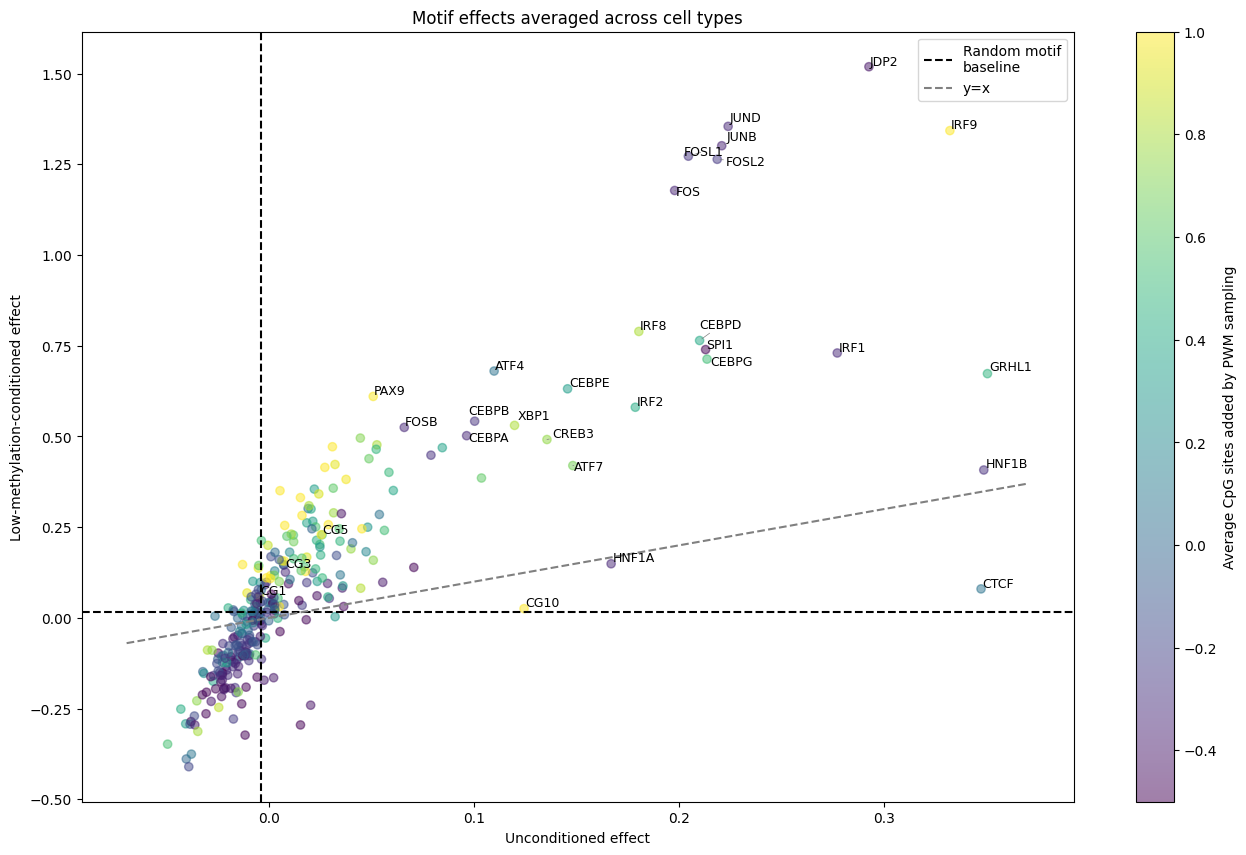

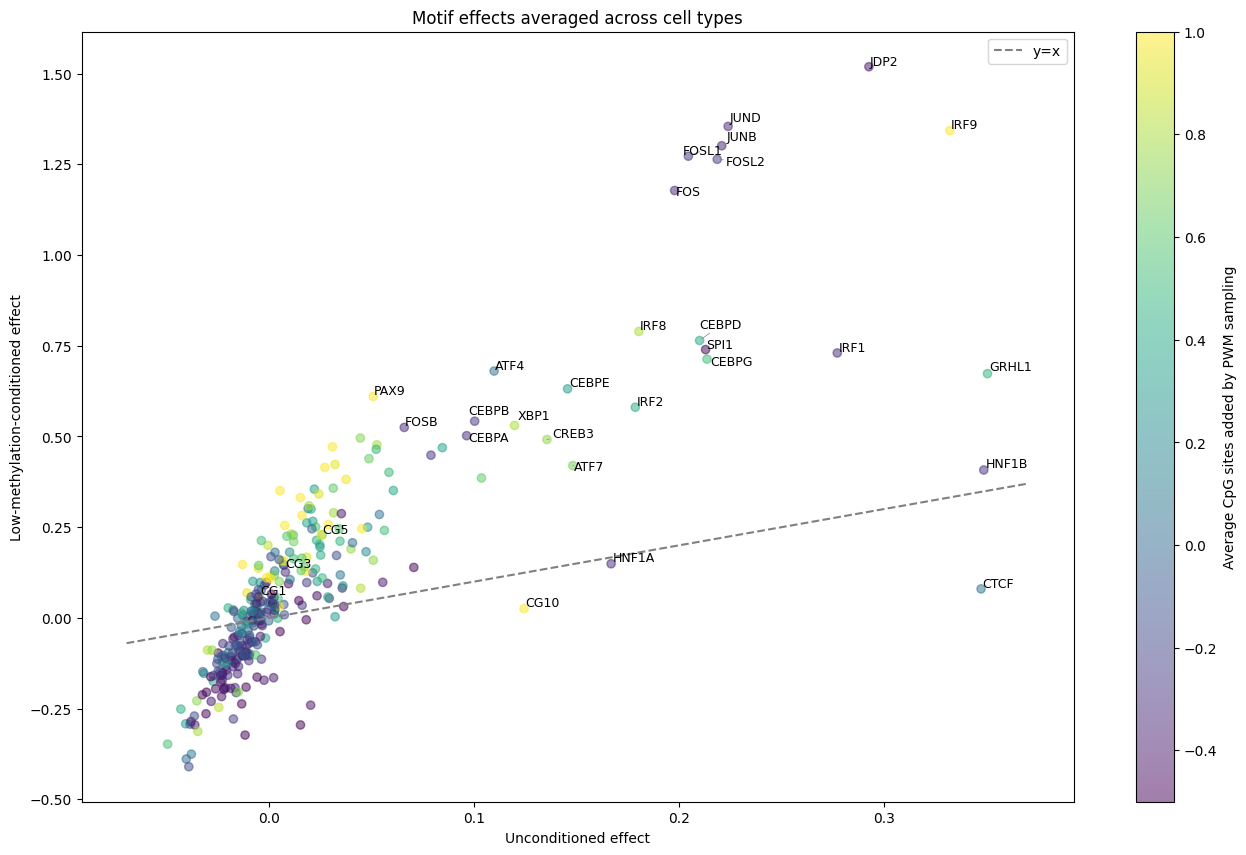

/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 25.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


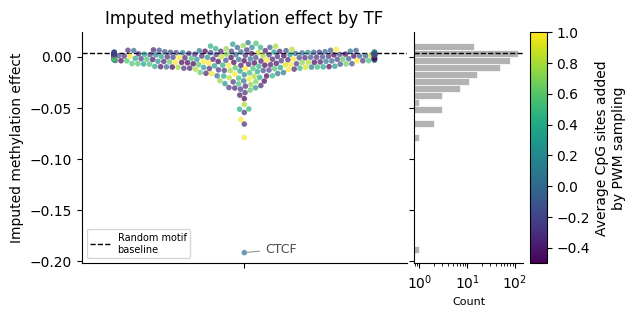

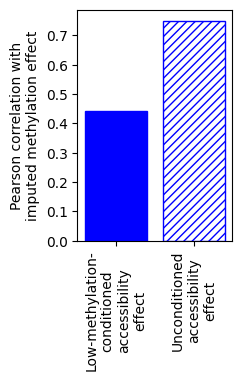

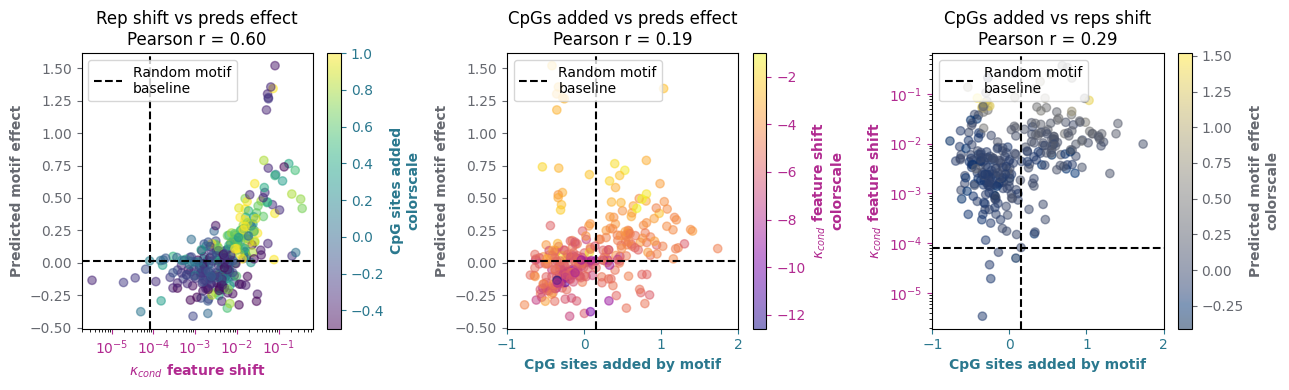

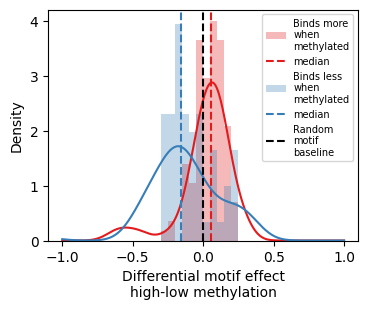

seq_only data types {'ATAC-seq'}, classify methyl-plus vs methyl-minus: AUC = 0.649, AUPRC = 0.532
synthetic_0.03 data types {'ATAC-seq'}, classify methyl-plus vs methyl-minus: AUC = 0.708, AUPRC = 0.606
synthetic_0.95 data types {'ATAC-seq'}, classify methyl-plus vs methyl-minus: AUC = 0.678, AUPRC = 0.543


/tmp/ipykernel_2941193/3370870828.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 25.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_2941193/3370870828.py:238: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar_ax.set_xticklabels(bar_ax.get_xticklabels(), rotation=90, fontsize=10)


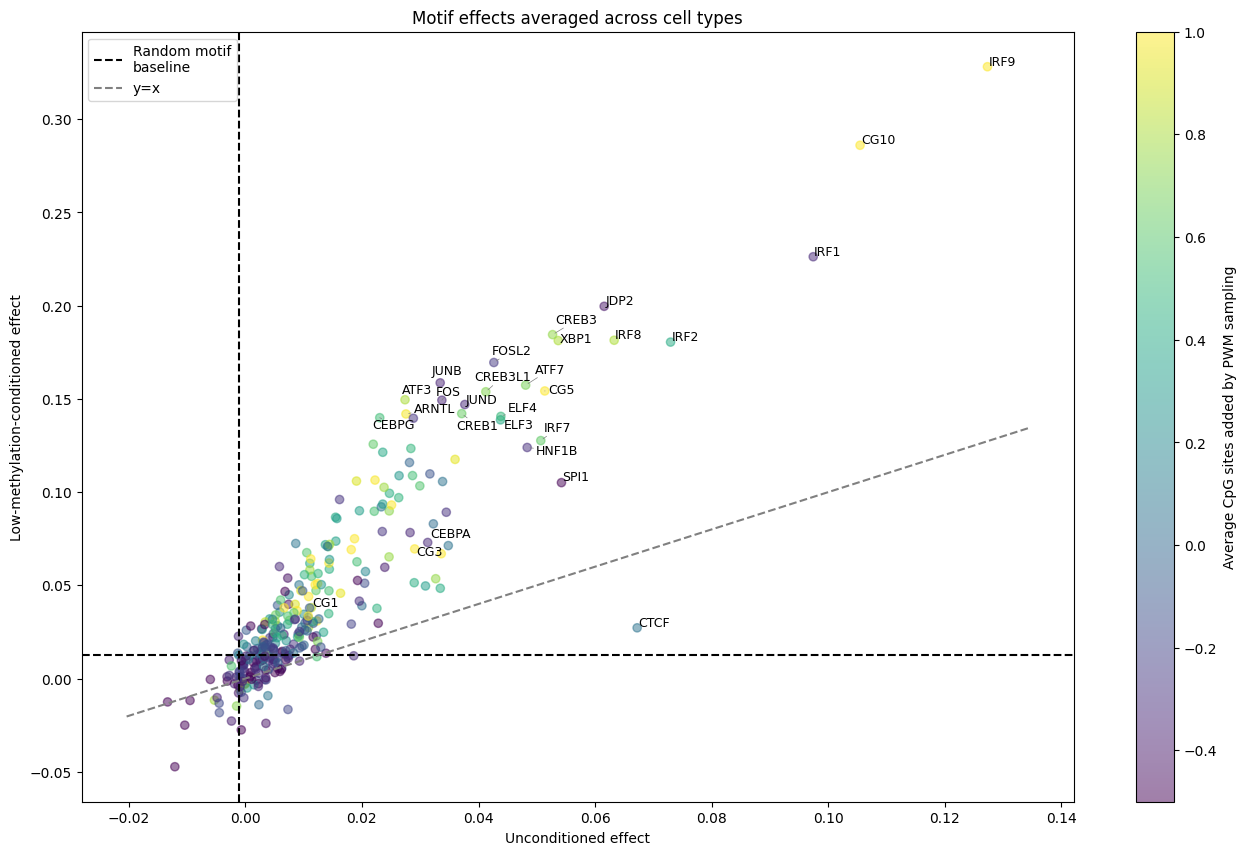

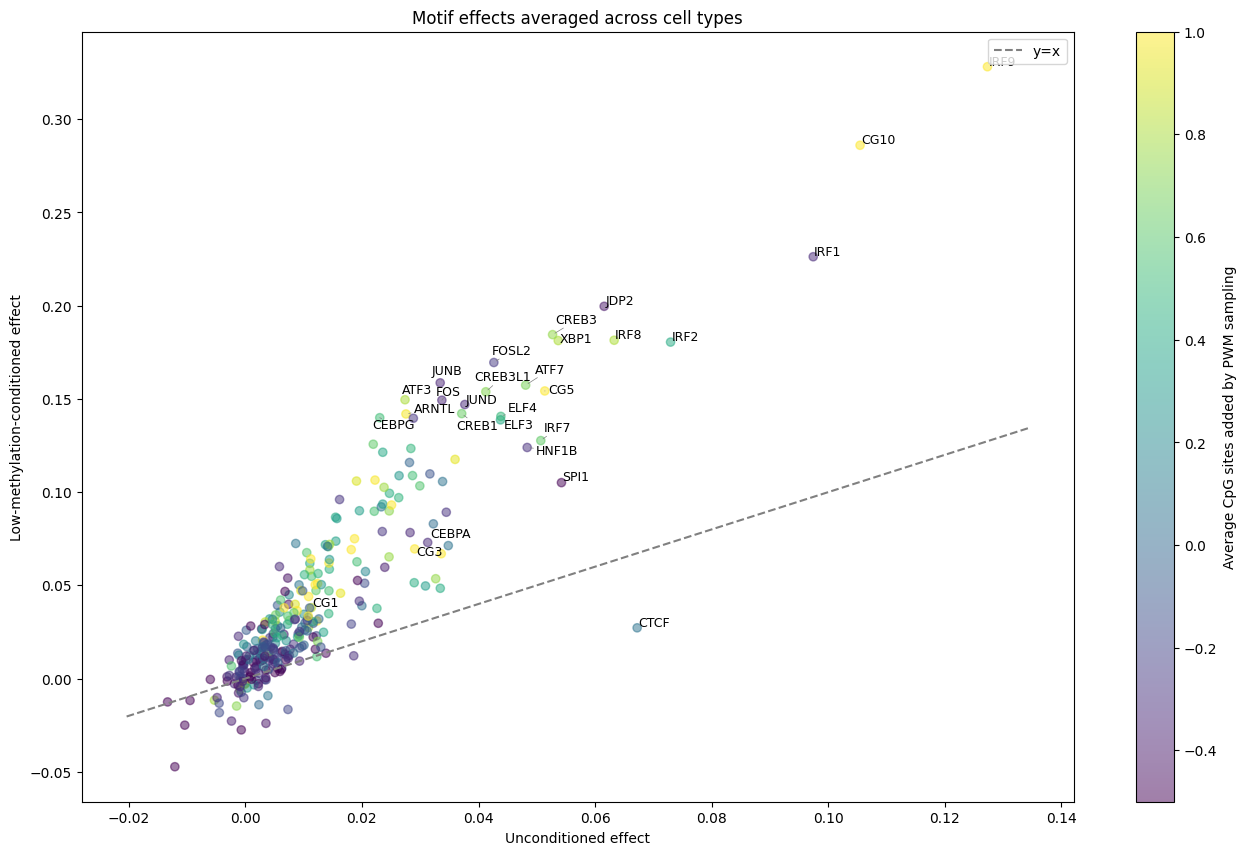

/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 25.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


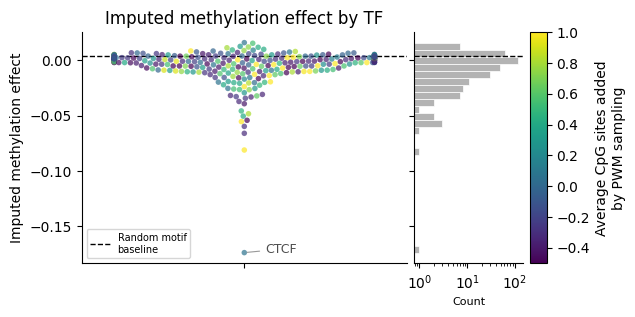

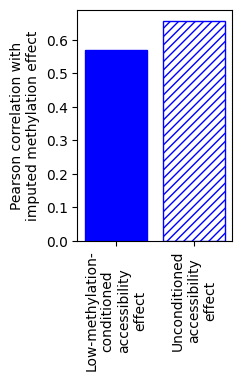

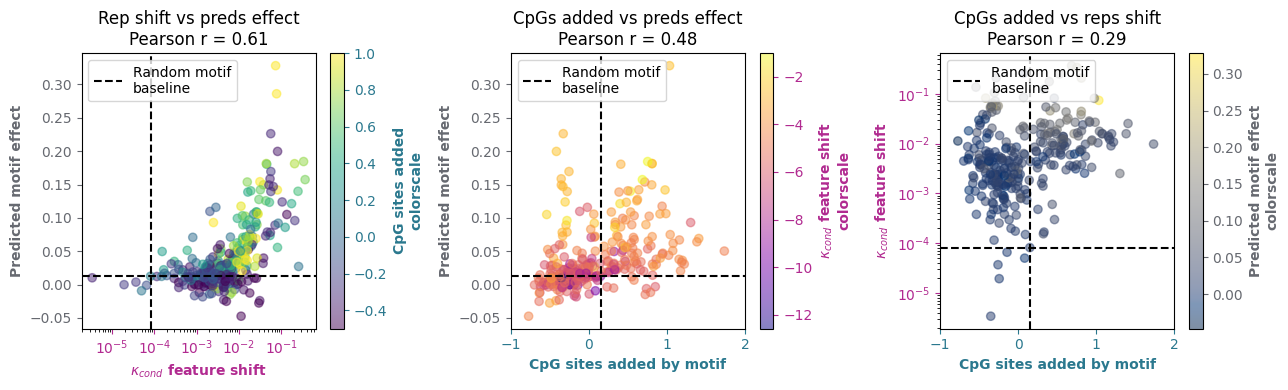

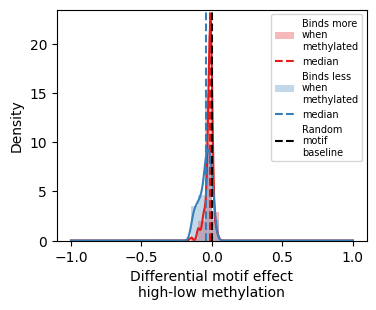

seq_only data types {'CAGE-seq'}, classify methyl-plus vs methyl-minus: AUC = 0.721, AUPRC = 0.662
synthetic_0.03 data types {'CAGE-seq'}, classify methyl-plus vs methyl-minus: AUC = 0.719, AUPRC = 0.667
synthetic_0.95 data types {'CAGE-seq'}, classify methyl-plus vs methyl-minus: AUC = 0.689, AUPRC = 0.621


In [23]:
# # nested: pickled_dict_description -> motif -> celltype_task -> value
# background_subtracted_mean_by_description = {}
# background_subtracted_std_by_description = {}
# background_subtracted_methylation_mean_by_description = {}
# data_types_by_description = {}

# # nested: pickled_dict_description -> motif -> value
# background_subtracted_cpgs_added_by_description = {}
# background_subtracted_mean_conditional_activations_by_description = {}
# background_subtracted_mean_unconditional_activations_by_description = {}

seq_model = "seq_only"
x_celltype = "all cell types"
low_methylation = "synthetic_0.03"
high_methylation = "synthetic_0.95"
y_celltype = "all cell types"
hox = [tf_name for tf_name in background_subtracted_mean_by_description[low_methylation].keys() if "HOX" in tf_name ]
ap1_tfs = tf_annotations[tf_annotations["AP-1 bool"]]["TF name"].tolist()
methyl_plus = tf_annotations[tf_annotations["Call"] == "MethylPlus"]["TF name"].tolist()
methyl_minus = tf_annotations[tf_annotations["Call"] == "MethylMinus"]["TF name"].tolist()
cpg_motifs = [tf_name for tf_name in background_subtracted_mean_by_description[low_methylation].keys() if "CG" in tf_name]
pioneer_motifs = tf_annotations[tf_annotations["Pioneer bool"]]["TF name"].tolist()
master_regulator_motifs = tf_annotations[tf_annotations["Master regulator bool"]]["TF name"].tolist()

for data_types_subset in [{"ATAC-seq",}, {"CAGE-seq",},]:
    tf_subset = ap1_tfs

    num_tfs_to_label_per_axis = 20
    additional_tfs_to_label = ["CG10", "CG5", "CG3", "CG1", "CEBPA"]
    tf_names = [tf_name for tf_name in background_subtracted_mean_by_description[low_methylation].keys()]
    unconditioned_effect = [np.array(
            [prediction for prediction, data_type in zip(celltypewise_dict.values(),celltype_datatypes.values()) if data_type in data_types_subset]
        ).mean() for celltypewise_dict,celltype_datatypes in zip(background_subtracted_mean_by_description[seq_model].values(),data_types_by_description[seq_model].values())]
    low_methylation_effect = [np.array(
            [prediction for prediction, data_type in zip(celltypewise_dict.values(),celltype_datatypes.values()) if data_type in data_types_subset]
        ).mean() for celltypewise_dict,celltype_datatypes in zip(background_subtracted_mean_by_description[low_methylation].values(),data_types_by_description[low_methylation].values())]
    unconditioned_random_effect = unconditioned_effect[tf_names.index("UNIFORMRANDOM10")]
    low_methylation_random_effect = low_methylation_effect[tf_names.index("UNIFORMRANDOM10")]
    high_methylation_effect = [np.array(
            [prediction for prediction, data_type in zip(celltypewise_dict.values(),celltype_datatypes.values()) if data_type in data_types_subset]
        ).mean() for celltypewise_dict,celltype_datatypes in zip(background_subtracted_mean_by_description[low_methylation].values(),data_types_by_description[high_methylation].values())]
    high_methylation_random_effect = high_methylation_effect[tf_names.index("UNIFORMRANDOM10")]
    cpg_added_vals = [background_subtracted_cpgs_added_by_description[low_methylation][tf_name] for tf_name in tf_names]
    # EITHER abs(conditionals - unconditionals).mean(peaks,features) OR abs(conditionals).mean(peaks,features) - abs(unconditionals).mean(peaks,features)
    absolute_embedding_shift = np.abs(np.array(
        [background_subtracted_mean_conditional_activations_by_description[low_methylation][tf_name] for tf_name in tf_names]
    ).mean(axis=(1,2))) #- np.abs(np.array(
        # [background_subtracted_mean_unconditional_activations_by_description[low_methylation][tf_name] for tf_name in tf_names]
    # )).mean(axis=(1,2))
    imputed_methylation_shift_methylseq = [np.array(
            [predicted_methylation for predicted_methylation, data_type in zip(celltypewise_dict.values(),celltype_datatypes.values()) if data_type in data_types_subset]
        ).mean() for celltypewise_dict,celltype_datatypes in zip(background_subtracted_methylation_mean_by_description[low_methylation].values(),data_types_by_description[low_methylation].values())]
    imputed_methylation_shift_seq_model = [np.array(
            [predicted_methylation for predicted_methylation, data_type in zip(celltypewise_dict.values(),celltype_datatypes.values()) if data_type in data_types_subset]
        ).mean() for celltypewise_dict,celltype_datatypes in zip(background_subtracted_methylation_mean_by_description[seq_model].values(),data_types_by_description[seq_model].values())]

    imputed_methylation_shift_random_methylseq = imputed_methylation_shift_methylseq[tf_names.index("UNIFORMRANDOM10")]
    imputed_methylation_shift_random_seq_model = imputed_methylation_shift_seq_model[tf_names.index("UNIFORMRANDOM10")]

    for include_random in [True, False]:
        scatter_fig, scatter_ax = plt.subplots(figsize=(16,10))
        sc = scatter_ax.scatter(
            unconditioned_effect,
            low_methylation_effect,
            c=cpg_added_vals,
            alpha=0.5,
            vmin=-.5,
            vmax=1,
        )
        if include_random:
            scatter_ax.axhline(low_methylation_random_effect, color="black", linestyle="--", label="Random motif\nbaseline")
            scatter_ax.axvline(unconditioned_random_effect, color="black", linestyle="--")
        # add y=x
        scatter_ax.plot([scatter_ax.get_xlim()[0], scatter_ax.get_xlim()[1]], [scatter_ax.get_xlim()[0], scatter_ax.get_xlim()[1]], color="gray", linestyle="--", label="y=x")
        scatter_ax.legend()
        plt.colorbar(sc, ax=scatter_ax, label=f"Average CpG sites added by PWM sampling")
        top_x = set(np.argsort(np.abs(unconditioned_effect))[-num_tfs_to_label_per_axis:])
        top_y = set(np.argsort(np.abs(low_methylation_effect))[-num_tfs_to_label_per_axis:])
        additional_idxs = set([tf_names.index(tf_name) for tf_name in additional_tfs_to_label if tf_name in tf_names])
        label_idxs = top_x | top_y | additional_idxs
        texts = []
        for i in label_idxs:
            texts.append(scatter_ax.annotate(
                tf_names[i],
                (unconditioned_effect[i], low_methylation_effect[i]),
                fontsize=9,
            ))

        adjust_text(texts, ax=scatter_ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

        scatter_ax.set_xlabel(f"Unconditioned effect")
        scatter_ax.set_ylabel(f"Low-methylation-conditioned effect")
        scatter_ax.set_title(f"Motif effects averaged across cell types")

        scatter_fig.savefig(f"pdfs/motif_insertion__{','.join(data_types_subset)}_unconditional_vs_conditional_includerandom{include_random}.pdf", format="pdf", bbox_inches="tight")

    # methyl_fig, methyl_axs = plt.subplots(1,2,figsize=(14,5))
    # num_tfs_to_label_per_axis_methyl = 10
    # methyl_axs[0].scatter(
    #     unconditioned_effect,
    #     -np.array(imputed_methylation_shift_methylseq),
    #     c=cpg_added_vals,
    #     alpha=0.5,
    #     vmin=-.5,
    #     vmax=1,
    # )
    # methyl_axs[0].axhline(unconditioned_random_effect, color="black", linestyle="--", label="Random motif\nbaseline")
    # methyl_axs[0].axvline(imputed_methylation_shift_random_methylseq, color="black", linestyle="--")
    pearson_unconditional_to_methyl = pearsonr(-np.array(imputed_methylation_shift_methylseq), unconditioned_effect)[0]
    # plt.colorbar(sc, ax=methyl_axs[0], label=f"CpG sites added by motif")
    # top_x = set(np.argsort(np.abs(imputed_methylation_shift_methylseq))[-num_tfs_to_label_per_axis_methyl:])
    # top_y = set(np.argsort(np.abs(unconditioned_effect))[-num_tfs_to_label_per_axis_methyl:])
    # additional_idxs = set([tf_names.index(tf_name) for tf_name in additional_tfs_to_label if tf_name in tf_names])
    # label_idxs = top_x | top_y | additional_idxs
    # texts = []
    # for i in label_idxs:
    #     texts.append(methyl_axs[0].annotate(
    #         tf_names[i],
    #         ( unconditioned_effect[i], -imputed_methylation_shift_methylseq[i],),
    #         fontsize=9,
    #     ))

    # adjust_text(texts, ax=methyl_axs[0], arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    # methyl_axs[0].set_ylabel(f"Imputed reduction in methylation")
    # methyl_axs[0].set_xlabel(f"Unconditioned effect")
    # methyl_axs[0].set_title(f"Unconditioned motif effects")
    # methyl_axs[0].text(
    #     0.7, 0.9, f"Pearson r = {pearson_unconditional_to_methyl:.2f}", transform=methyl_axs[0].transAxes, fontsize=10,
    # )
    # methyl_axs[1].scatter(
    #     low_methylation_effect,
    #     -np.array(imputed_methylation_shift_methylseq),
    #     c=cpg_added_vals,
    #     alpha=0.5,
    #     vmin=-.5,
    #     vmax=1,
    # )
    # methyl_axs[1].axhline(low_methylation_random_effect, color="black", linestyle="--", label="Random motif\nbaseline")
    # methyl_axs[1].axvline(imputed_methylation_shift_random_methylseq, color="black", linestyle="--")
    pearson_conditional_to_methyl = pearsonr(-np.array(imputed_methylation_shift_methylseq), low_methylation_effect)[0]
    # plt.colorbar(sc, ax=methyl_axs[1], label=f"CpG sites added by motif")
    # top_x = set(np.argsort(np.abs(imputed_methylation_shift_methylseq))[-num_tfs_to_label_per_axis_methyl:])
    # top_y = set(np.argsort(np.abs(low_methylation_effect))[-num_tfs_to_label_per_axis_methyl:])
    # additional_idxs = set([tf_names.index(tf_name) for tf_name in additional_tfs_to_label if tf_name in tf_names])
    # label_idxs = top_x | top_y | additional_idxs
    # texts = []
    # for i in label_idxs:
    #     texts.append(methyl_axs[1].annotate(
    #         tf_names[i],
    #         ( low_methylation_effect[i], -imputed_methylation_shift_methylseq[i],),
    #         fontsize=9,
    #     ))
    # adjust_text(texts, ax=methyl_axs[1], arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    # methyl_axs[1].set_ylabel(f"Imputed reduction in methylation")
    # methyl_axs[1].set_xlabel(f"Low-methylation-conditioned motif effect")
    # methyl_axs[1].set_title(f"Conditioned motif effects")
    # methyl_axs[1].text(
    #     0.7, 0.9, f"Pearson r = {pearson_conditional_to_methyl:.2f}", transform=methyl_axs[1].transAxes, fontsize=10,
    # )
    # methyl_fig.savefig(f"pdfs/motif_insertion__{','.join(data_types_subset)}_methylation_correlation.pdf", format="pdf", bbox_inches="tight")

    fig = plt.figure(figsize=(6, 3))

    # GridSpec: swarm | histogram | colorbar
    gs = fig.add_gridspec(1, 3, width_ratios=[3, 1, 0.15], wspace=0.05)
    ax = fig.add_subplot(gs[0])
    hist_ax = fig.add_subplot(gs[1], sharey=ax)
    cbar_ax = fig.add_subplot(gs[2])

    # Color mapping
    norm = mcolors.Normalize(vmin=-0.5, vmax=1.0)
    cmap = cm.viridis
    colors = cmap(norm(cpg_added_vals))

    # Swarm plot — use a neutral color first, then recolor
    sns.swarmplot(y=imputed_methylation_shift_seq_model, ax=ax, color="gray", size=4, alpha=0.7)
    ax.collections[0].set_facecolors(colors)
    ax.collections[0].set_edgecolors("none")

    # Dashed line at the random baseline
    baseline_val = imputed_methylation_shift_seq_model[tf_names.index("UNIFORMRANDOM10")]
    ax.axhline(baseline_val, ls="--", color="black", lw=1, label="Random motif\nbaseline")

    # CTCF annotation
    ctcf_idx = tf_names.index("CTCF")
    offsets = ax.collections[0].get_offsets()
    ctcf_x, ctcf_y = offsets[ctcf_idx]
    ax.annotate(
        "CTCF",
        xy=(ctcf_x, ctcf_y),
        xytext=(15, 0),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="-", color="0.6", lw=0.8),
        fontsize=9,
        color="0.3",
    )

    ax.legend(fontsize=7, loc="best")
    ax.set_ylabel("Imputed methylation effect")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title("Imputed methylation effect by TF")

    # Marginal histogram on the right (log-scale x)
    hist_ax.hist(
        imputed_methylation_shift_seq_model,
        bins=30,
        orientation="horizontal",
        color="0.7",
        edgecolor="white",
        linewidth=0.5,
    )
    hist_ax.axhline(baseline_val, ls="--", color="black", lw=1)
    hist_ax.set_xscale("log")
    hist_ax.set_xlabel("Count", fontsize=8)
    hist_ax.tick_params(labelleft=False)
    hist_ax.spines["top"].set_visible(False)
    hist_ax.spines["right"].set_visible(False)

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Average CpG sites added\nby PWM sampling")

    fig.tight_layout()
    fig.savefig(f"pdfs/motif_insertion__{','.join(data_types_subset)}_imputed_methylation_swarm.pdf", format="pdf", bbox_inches="tight")

    bar_fig, bar_ax = plt.subplots(figsize=(2,3))
    bar_ax.bar(
        ["Low-methylation-\nconditioned\naccessibility\neffect", "Unconditioned\naccessibility\neffect"],
        [pearson_conditional_to_methyl, pearson_unconditional_to_methyl],
        color=["blue","white"],
        hatch=["","////"],
        edgecolor=["blue","blue"],
    )
    # set labels to 90 degrees    
    bar_ax.set_xticklabels(bar_ax.get_xticklabels(), rotation=90, fontsize=10)
    bar_ax.set_ylabel("Pearson correlation with\nimputed methylation effect")
    bar_fig.savefig(f"pdfs/motif_insertion__{','.join(data_types_subset)}_correlation_bar.pdf", format="pdf", bbox_inches="tight")

    sc2_fig, sc2_axs = plt.subplots(1,3,figsize=(13,4))
    cmap0 = LinearSegmentedColormap.from_list('gray_blue',   ['#808080', '#1f77b4'])
    cmap1 = LinearSegmentedColormap.from_list('gray_orange', ['#808080', '#ff7f0e'])
    cmap2 = LinearSegmentedColormap.from_list('gray_green',  ['#808080', '#2ca02c'])
    sc0 = sc2_axs[0].scatter(
        absolute_embedding_shift,
        low_methylation_effect,
        c=np.clip(cpg_added_vals,-.5,1),
        alpha=0.5,
        cmap='viridis',
    )
    sc1 = sc2_axs[1].scatter(
        cpg_added_vals,
        low_methylation_effect,
        c=np.log(absolute_embedding_shift),
        alpha=0.5,
        cmap='plasma',
    )
    sc2 = sc2_axs[2].scatter(
        cpg_added_vals,
        absolute_embedding_shift,
        c=low_methylation_effect,
        alpha=0.5,
        cmap='cividis',
    )
    target_color_value = 0.4
    c_cpg      = plt.cm.viridis(target_color_value)   # cpg is the color variable in ax0
    c_absshift = plt.cm.plasma(target_color_value)    # abs_shift is the color variable in ax1
    c_yvals    = plt.cm.cividis(target_color_value)   # low_methylation_effect is the color variable in ax2
    pearson_cpg_to_cond = pearsonr(cpg_added_vals, low_methylation_effect)[0]
    pearson_emb_shift_to_cond = pearsonr(np.log(absolute_embedding_shift), low_methylation_effect)[0]
    pearson_cpg_to_emb_shift = pearsonr(cpg_added_vals, np.log(absolute_embedding_shift))[0]
    ur10_emb_shift = absolute_embedding_shift[tf_names.index("UNIFORMRANDOM10")]
    ur10_cpg_added = cpg_added_vals[tf_names.index("UNIFORMRANDOM10")]
    ur10_cond_shift = low_methylation_effect[tf_names.index("UNIFORMRANDOM10")]
    sc2_axs[0].set_xlabel(r"$\kappa_{cond}$ feature shift",fontweight='bold')
    sc2_axs[0].set_ylabel(f"Predicted motif effect", fontweight='bold')
    sc2_axs[0].set_title(f"Rep shift vs preds effect\nPearson r = {pearson_emb_shift_to_cond:.2f}")

    # ax0: x=abs_shift (plasma), y=low_methylation_effect (cividis)
    sc2_axs[0].xaxis.label.set_color(c_absshift)
    sc2_axs[0].tick_params(axis='x', colors=c_absshift)
    sc2_axs[0].yaxis.label.set_color(c_yvals)
    sc2_axs[0].tick_params(axis='y', colors=c_yvals)

    # sc2_axs[0].set_xlim(0.3, 0.9)
    # sc2_axs[0].set_xlim(0.03,0.05)
    sc2_axs[0].semilogx()
    sc2_axs[1].set_xlabel(f"CpG sites added by motif", fontweight='bold')
    sc2_axs[1].set_ylabel(f"Predicted motif effect", fontweight='bold')
    sc2_axs[1].set_title(f"CpGs added vs preds effect\nPearson r = {pearson_cpg_to_cond:.2f}")
    sc2_axs[1].set_xlim(-1, 2)

    # ax1: x=cpg (viridis), y=low_methylation_effect (cividis)
    sc2_axs[1].xaxis.label.set_color(c_cpg)
    sc2_axs[1].tick_params(axis='x', colors=c_cpg)
    sc2_axs[1].yaxis.label.set_color(c_yvals)
    sc2_axs[1].tick_params(axis='y', colors=c_yvals)

    sc2_axs[2].set_xlabel(f"CpG sites added by motif", fontweight='bold')
    sc2_axs[2].set_ylabel(r"$\kappa_{cond}$ feature shift", fontweight='bold')
    sc2_axs[2].set_title(f"CpGs added vs reps shift\nPearson r = {pearson_cpg_to_emb_shift:.2f}")
    sc2_axs[2].set_xlim(-1, 2)
    sc2_axs[2].semilogy()

    # ax2: x=cpg (viridis), y=abs_shift (plasma)
    sc2_axs[2].xaxis.label.set_color(c_cpg)
    sc2_axs[2].tick_params(axis='x', colors=c_cpg)
    sc2_axs[2].yaxis.label.set_color(c_absshift)
    sc2_axs[2].tick_params(axis='y', colors=c_absshift)

    sc2_axs[0].axhline(ur10_cond_shift, color="black", linestyle="--", label="Random motif\nbaseline")
    sc2_axs[1].axhline(ur10_cond_shift, color="black", linestyle="--", label="Random motif\nbaseline")
    sc2_axs[2].axhline(ur10_emb_shift, color="black", linestyle="--", label="Random motif\nbaseline")
    sc2_axs[0].axvline(ur10_emb_shift, color="black", linestyle="--")
    sc2_axs[1].axvline(ur10_cpg_added, color="black", linestyle="--")
    sc2_axs[2].axvline(ur10_cpg_added, color="black", linestyle="--")
    sc2_axs[0].legend(loc="upper left")
    sc2_axs[1].legend(loc="upper left")
    sc2_axs[2].legend(loc="upper left")

    cb0 = plt.colorbar(sc0, ax=sc2_axs[0])
    cb1 = plt.colorbar(sc1, ax=sc2_axs[1])
    cb2 = plt.colorbar(sc2, ax=sc2_axs[2])

    # Label and color them to match
    cb0.set_label("CpG sites added\ncolorscale", color=c_cpg, fontweight='bold')
    cb1.set_label(r"$\kappa_{cond}$ feature shift"+"\ncolorscale", color=c_absshift, fontweight='bold')
    cb2.set_label("Predicted motif effect\ncolorscale", color=c_yvals, fontweight='bold')

    # Color the colorbar tick labels too
    cb0.ax.yaxis.set_tick_params(color=c_cpg)
    cb1.ax.yaxis.set_tick_params(color=c_absshift)
    cb2.ax.yaxis.set_tick_params(color=c_yvals)

    for label in cb0.ax.get_yticklabels():
        label.set_color(c_cpg)
    for label in cb1.ax.get_yticklabels():
        label.set_color(c_absshift)
    for label in cb2.ax.get_yticklabels():
        label.set_color(c_yvals)

    sc2_fig.tight_layout()
    sc2_fig.savefig(f"pdfs/motif_insertion__{','.join(data_types_subset)}_embedding_shift_cpg_correlation.pdf", format="pdf", bbox_inches="tight")

    # hist_fig, hist_axs = plt.subplots(1,4,figsize=(18,4))
    hist2_fig, hist2_ax = plt.subplots(figsize=(4,3))

    shifts_by_subset = defaultdict(dict)

    colors = plt.get_cmap('Set1').colors

    upreg_string = "Binds more\nwhen\nmethylated"
    downreg_string = "Binds less\nwhen\nmethylated"

    for subset_idx, (subset_name, tf_subset) in enumerate([
        # ("AP-1 family TFs", ap1_tfs),
        (upreg_string, methyl_plus),
        (downreg_string, methyl_minus),
        # ["pioneer TFs", pioneer_motifs],
        # ["master regulator TFs", master_regulator_motifs],
        # ("Cpg motifs", cpg_motifs),
    ]):
        tf_in_subset = [any(tf_from_subset == tf_name for tf_from_subset in tf_subset) for tf_name in tf_names]

        shifts_by_subset[subset_name][seq_model] = np.array(        
            [np.array(
                [prediction for prediction, data_type in zip(celltypewise_dict.values(),celltype_datatypes.values()) if data_type in data_types_subset]
            ).mean() for celltypewise_dict,celltype_datatypes in zip(background_subtracted_mean_by_description[seq_model].values(),data_types_by_description[seq_model].values())]
        )[tf_in_subset]
        # hist_axs[0].hist(
        #     shifts_by_subset[subset_name][seq_model],
        #     alpha=0.3,
        #     label=subset_name,
        #     density=True,
        #     bins=np.arange(-0.1,.1,0.005),
        #     color=colors[subset_idx % len(colors)]
        # )
        # hist_axs[0].legend()
        # hist_axs[0].set_title(f"{seq_model}")
        # hist_axs[0].set_xlabel(f"Background-subtracted\nmean prediction\n{data_types_subset}")
        # hist_axs[0].set_ylabel("Density")
        shifts_by_subset[subset_name][low_methylation] = np.array(
            [np.array(
                [prediction for prediction, data_type in zip(celltypewise_dict.values(),celltype_datatypes.values()) if data_type in data_types_subset]
            ).mean() for celltypewise_dict,celltype_datatypes in zip(background_subtracted_mean_by_description[low_methylation].values(),data_types_by_description[low_methylation].values())]
        )[tf_in_subset]
        # hist_axs[1].hist(
        #     shifts_by_subset[subset_name][low_methylation],
        #     alpha=0.3,
        #     label=subset_name,
        #     density=True,
        #     bins=np.arange(-1,1,0.05),
        #     color=colors[subset_idx % len(colors)],
        # )
        # kde = gaussian_kde(shifts_by_subset[subset_name][low_methylation])
        # x_range = np.linspace(-1, 1, 300)
        # hist_axs[1].plot(x_range, kde(x_range), color=colors[subset_idx % len(colors)], linewidth=1.5)
        # hist_axs[1].axvline(np.median(shifts_by_subset[subset_name][low_methylation]), color=colors[subset_idx % len(colors)], linestyle="--", label=f"median")
        # hist_axs[1].legend(fontsize=8,loc="upper right")
        # hist_axs[1].set_title(f"Conditioned on low methylation")
        # hist_axs[1].set_xlabel(f"Background-subtracted\nmean prediction\n{','.join(data_types_subset)}")
        # hist_axs[1].set_ylabel("Density")
        shifts_by_subset[subset_name][high_methylation] = np.array(
            [np.array(
                [prediction for prediction, data_type in zip(celltypewise_dict.values(),celltype_datatypes.values()) if data_type in data_types_subset]
            ).mean() for celltypewise_dict,celltype_datatypes in zip(background_subtracted_mean_by_description[high_methylation].values(),data_types_by_description[high_methylation].values())]
        )[tf_in_subset]
        # hist_axs[2].hist(
        #     shifts_by_subset[subset_name][high_methylation],
        #     alpha=0.3,
        #     label=subset_name,
        #     density=True,
        #     bins=np.arange(-.1,.1,0.005),
        #     color=colors[subset_idx % len(colors)]
        # )
        # hist_axs[2].legend()
        # hist_axs[2].set_title(f"Conditioned on high methylation")
        # hist_axs[2].set_xlabel(f"Background-subtracted\nmean prediction\n{data_types_subset}")
        # hist_axs[2].set_ylabel("Density")

        hist2_ax.hist(
            shifts_by_subset[subset_name][high_methylation] - shifts_by_subset[subset_name][low_methylation],
            alpha=0.3,
            label=subset_name,
            density=True,
            bins=np.arange(-.3,.3,0.05),
            color=colors[subset_idx % len(colors)],
        )
        kde = gaussian_kde(shifts_by_subset[subset_name][high_methylation] - shifts_by_subset[subset_name][low_methylation])
        x_range = np.linspace(-1, 1, 300)
        hist2_ax.plot(x_range, kde(x_range), color=colors[subset_idx % len(colors)], linewidth=1.5)
        hist2_ax.axvline(np.median(shifts_by_subset[subset_name][high_methylation] - shifts_by_subset[subset_name][low_methylation]), color=colors[subset_idx % len(colors)], linestyle="--", label=f"median")
        # hist2_ax.set_title(f"Differential activity between\nhigh and low methylation")
        hist2_ax.set_xlabel(f"Differential motif effect\nhigh-low methylation")
        hist2_ax.set_ylabel("Density")
    hist2_ax.axvline(high_methylation_random_effect - low_methylation_random_effect, color="black", linestyle="--", label="Random\nmotif\nbaseline")
    hist2_ax.legend(fontsize=7,loc="upper right")
    hist2_fig.savefig(f"pdfs/motif_insertion__{','.join(data_types_subset)}_high_minus_low_methylation_hist.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    labels = np.array([0] * len(shifts_by_subset[upreg_string][low_methylation]) + [1] * len(shifts_by_subset[downreg_string][low_methylation]))
    # print(shifts_by_subset)
    for key, name in [(seq_model, seq_model), (low_methylation, low_methylation), (high_methylation, high_methylation)]:
        scores = np.concatenate([shifts_by_subset[upreg_string][key],
                                shifts_by_subset[downreg_string][key]])
        auc = roc_auc_score(labels, scores)
        # Flip if AUC < 0.5 (scores go the other direction)
        fpr, tpr, _ = roc_curve(labels, scores if auc == roc_auc_score(labels, scores) else -scores)
        precision, recall, _ = precision_recall_curve(labels, scores)
        ap = average_precision_score(labels, scores)
        print(f"{name} data types {data_types_subset}, classify methyl-plus vs methyl-minus: AUC = {auc:.3f}, AUPRC = {ap:.3f}")

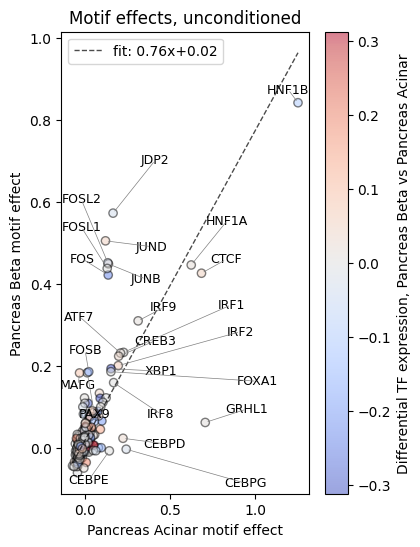

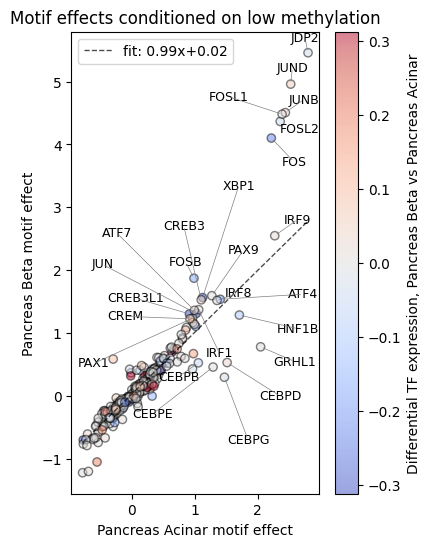

In [32]:
# celltype_1_name = "Blood-B"
# celltype_2_name = "Blood-NK"

# celltype_1_name = "Blood-T-Naive-CD4"
# celltype_2_name = "Blood-T-Naive-CD8"

celltype_1_name = "Pancreas-Acinar"
celltype_2_name = "Pancreas-Beta"

# celltype_1_name = "Blood-B"
# celltype_2_name = "Neuron"

# celltype_1_name = "Blood-B"
# celltype_2_name = "Blood-T-Naive-CD8"

# celltype_1_name = "Heart-Cardiomyocyte"
# celltype_2_name = "Heart-Fibroblast"

tf_subset_by_model = {}

data_type = 'ATAC-seq'

for description, model in (", unconditioned","seq_only"),(" conditioned on low methylation","synthetic_0.03"):

    scatter_fig, scatter_axs = plt.subplots(1,1,figsize=(4,6))

    celltype_1 = io_mappings_df[(io_mappings_df["methylation_files"].str.contains(celltype_1_name)) & (io_mappings_df["data_type"] == data_type)]["absolute_channel"].values[0]
    celltype_2 = io_mappings_df[(io_mappings_df["methylation_files"].str.contains(celltype_2_name)) & (io_mappings_df["data_type"] == data_type)]["absolute_channel"].values[0]

    expression_in_ct1 = [tf_expression_df[tf_expression_df["TF"]==tf][task_index_to_expression_column[celltype_1]].values[0]
        for tf in background_subtracted_mean_by_description[model].keys()]
    expression_in_ct2 = [np.array([tf_expression_df[tf_expression_df["TF"]==tf][task_index_to_expression_column[celltype_2]].values[0]
        for tf in background_subtracted_mean_by_description[model].keys()])]
        
    num_tfs_to_label_per_axis = 20
    tf_names = [tf_name for tf_name in background_subtracted_mean_by_description[low_methylation].keys()]

    x_vals = np.array([np.array((celltypewise_dict[celltype_1])) for celltypewise_dict in background_subtracted_mean_by_description[model].values()])
    y_vals = np.array([np.array((celltypewise_dict[celltype_2])) for celltypewise_dict in background_subtracted_mean_by_description[model].values()])

    diff_expr = np.array(expression_in_ct2) - np.array(expression_in_ct1)
    absmax = np.percentile(np.abs(diff_expr), 95)  # robust to outliers

    sc = scatter_axs.scatter(
        x_vals,
        y_vals,
        c=diff_expr,
        # alpha=0.5,
        cmap='coolwarm',
        vmin=-absmax,
        vmax=absmax,
        edgecolors='black',
        linewidths=1,
        # label="TFs colored by\nexpression difference\nbetween cell types"
    )
    sc.set_alpha(0.5)
    plt.colorbar(sc, ax=scatter_axs, label=f"Differential TF expression, {celltype_2_name.replace('-',' ')} vs {celltype_1_name.replace('-',' ')}")
    res = siegelslopes(y_vals, x_vals)
    x_line = np.linspace(min(x_vals), max(x_vals), 100)
    scatter_axs.plot(x_line, res.slope * x_line + res.intercept, color='black', linestyle="--", linewidth=1, alpha=0.7,label=f"fit: {res.slope:.2f}x+{res.intercept:.2f}")
    scatter_axs.legend()

    scatter_axs.set_xlabel(f"{celltype_1_name.replace('-',' ')} motif effect")
    scatter_axs.set_ylabel(f"{celltype_2_name.replace('-',' ')} motif effect")

    scatter_axs.set_title(f"Motif effects{description}")

    top_x = set(np.argsort(np.abs(x_vals))[-num_tfs_to_label_per_axis:])
    top_y = set(np.argsort(np.abs(y_vals))[-num_tfs_to_label_per_axis:])
    label_idxs = top_x | top_y
    tf_subset_by_model[model] = [tf_names[i] for i in label_idxs]
    texts = []
    for i in label_idxs:
        texts.append(scatter_axs.annotate(
            tf_names[i],
            (x_vals[i], y_vals[i]),
            fontsize=9,
        ))
    adjust_text(
        texts,
        ax=scatter_axs,
        expand=(2.0, 2.0),          # expand bounding boxes before checking overlap (default 1.05)
        force_text=(0.5, 0.5),      # force pushing overlapping texts apart
        force_points=(0.3, 0.3),    # force pushing texts away from points
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
        iter_lim=500,                # more iterations to converge
    )

    scatter_fig.savefig(f"pdfs/motif_insertion__{data_type}_{model}_scatter_{celltype_1_name}_vs_{celltype_2_name}.pdf", format="pdf", bbox_inches="tight")

plt.show()

6


  0%|          | 0/35 [00:00<?, ?it/s]

/tmp/ipykernel_3129800/3276646784.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = pearsonr(celltype_inserted_mean, celltype_expression_mean)
/tmp/ipykernel_3129800/3276646784.py:34: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(celltype_inserted_mean, celltype_expression_mean)


6


  0%|          | 0/35 [00:00<?, ?it/s]

6


  0%|          | 0/28 [00:00<?, ?it/s]

/tmp/ipykernel_3129800/3276646784.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = pearsonr(celltype_inserted_mean, celltype_expression_mean)
/tmp/ipykernel_3129800/3276646784.py:34: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(celltype_inserted_mean, celltype_expression_mean)


6


  0%|          | 0/28 [00:00<?, ?it/s]

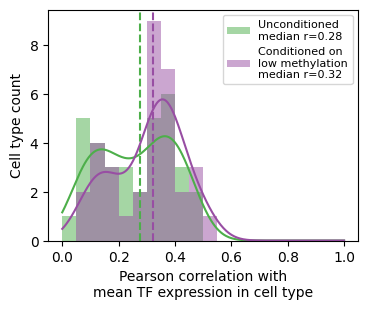

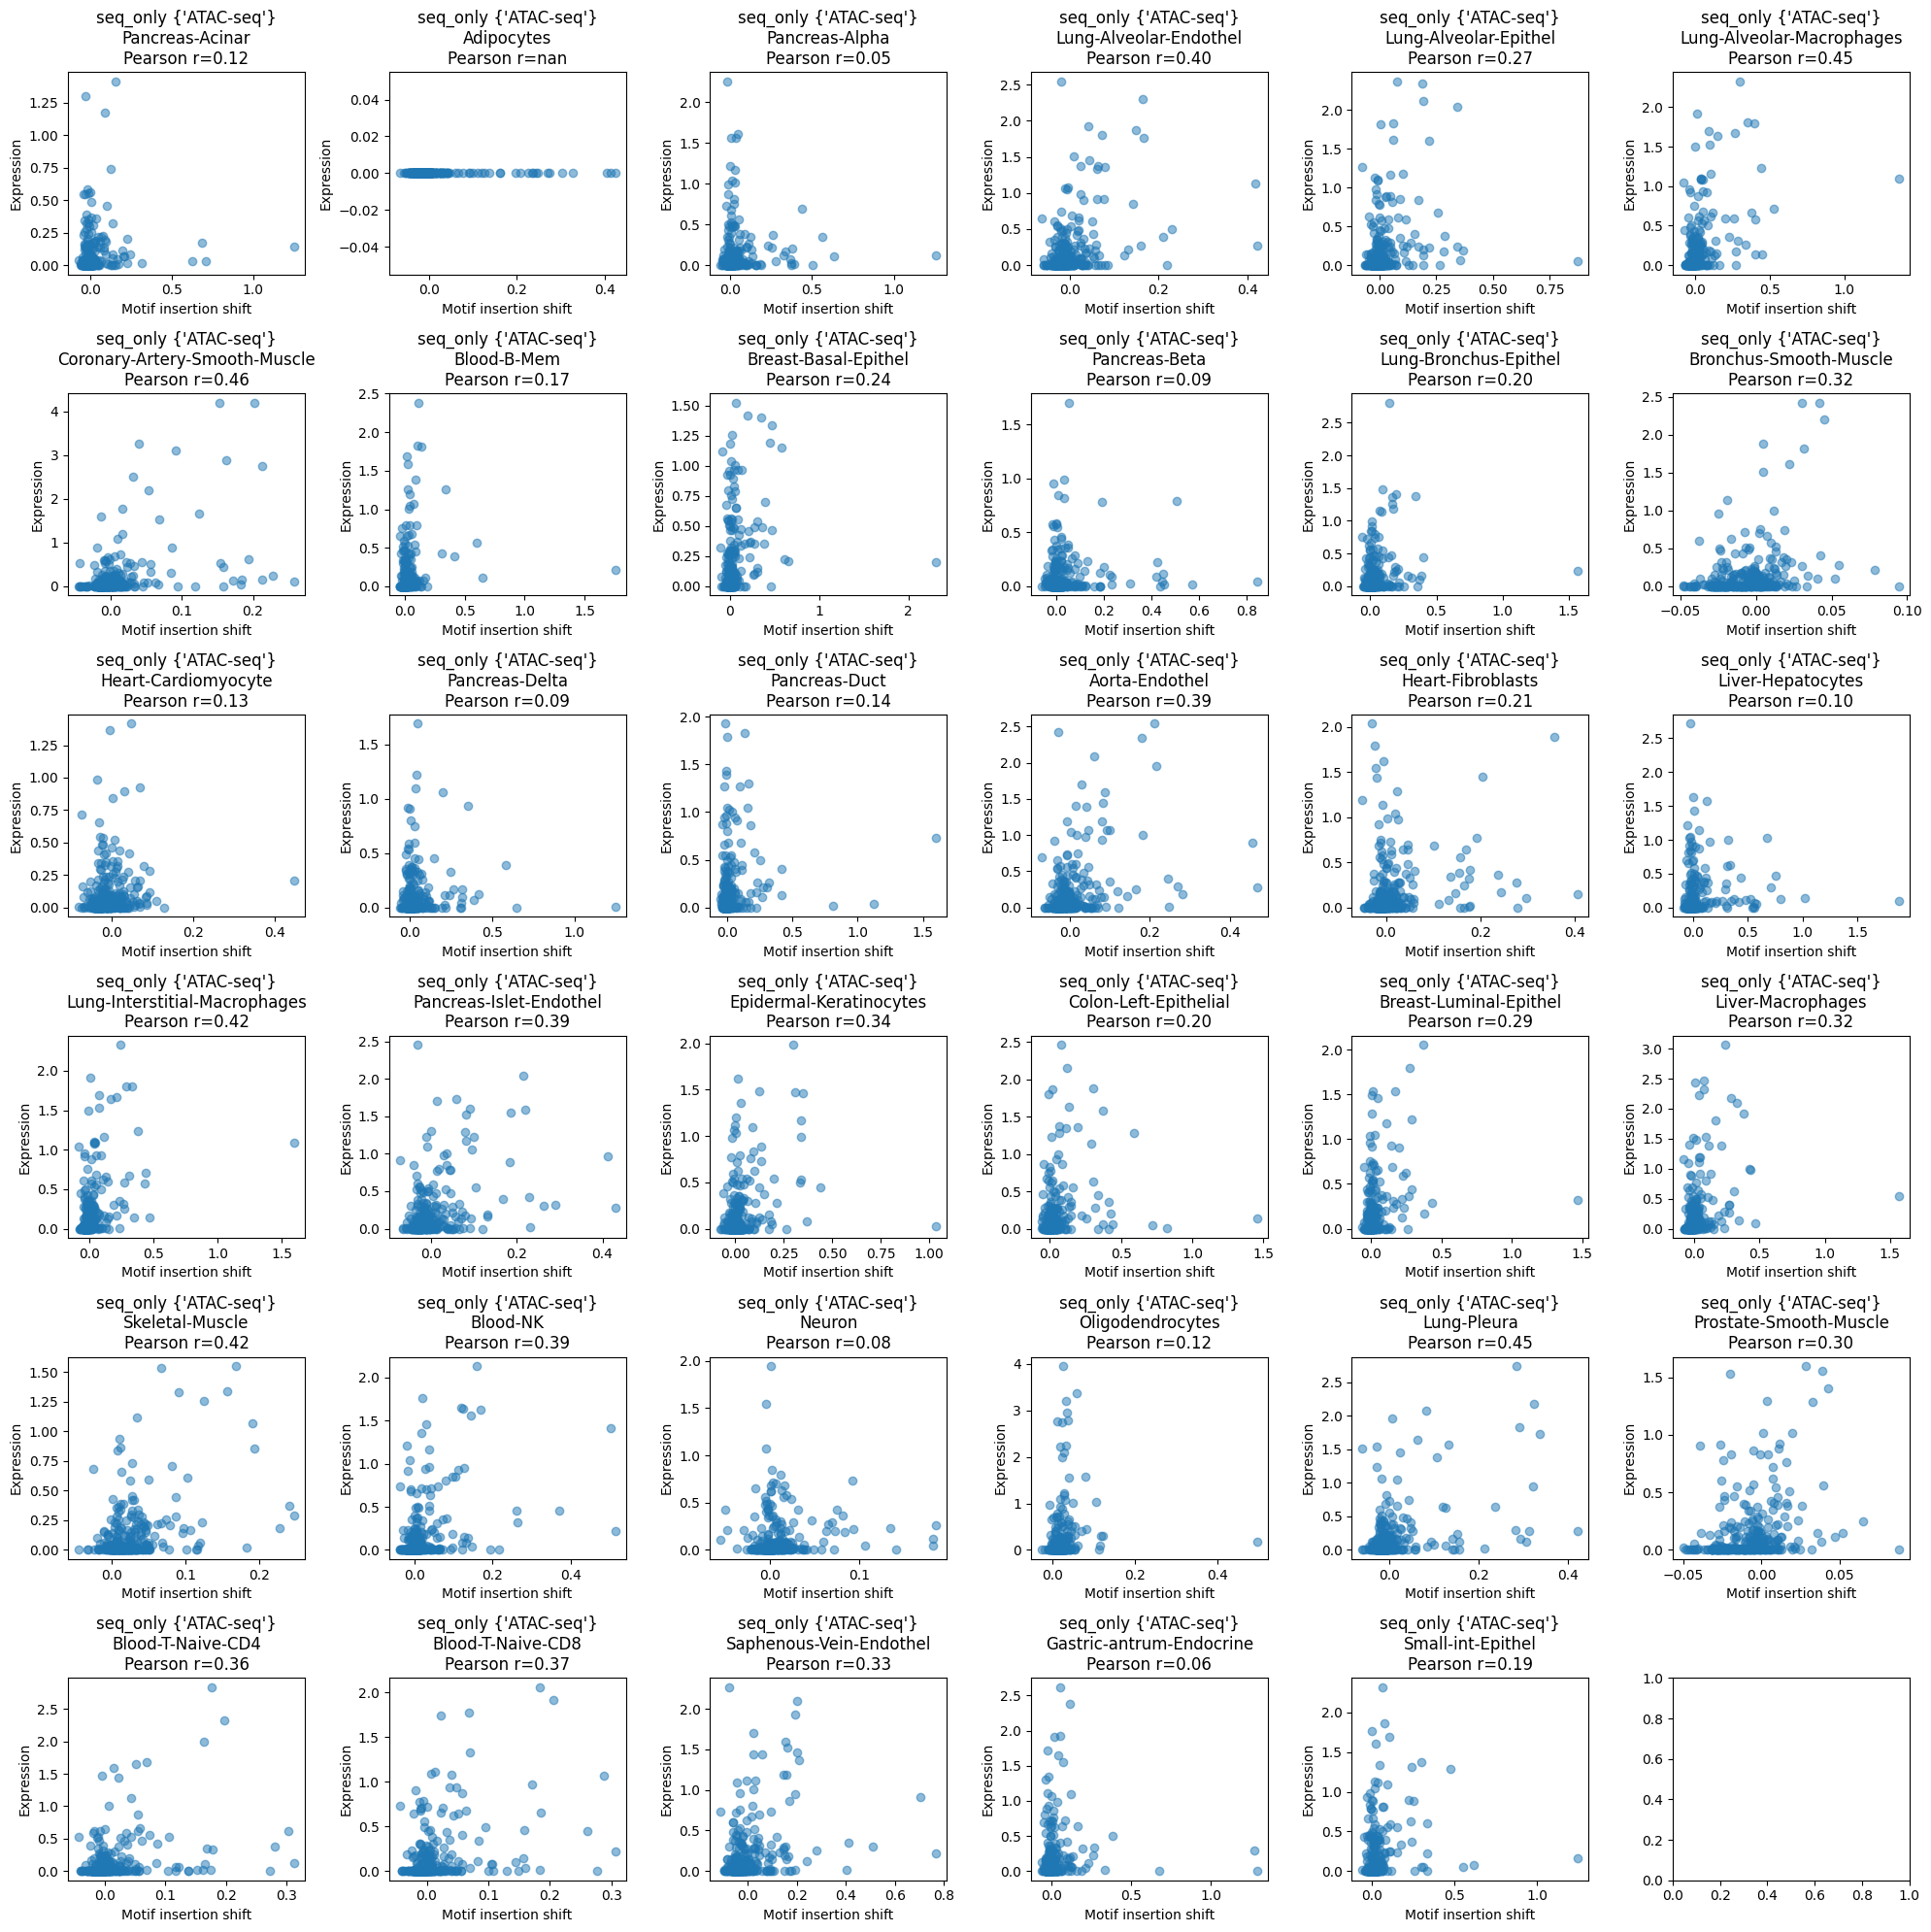

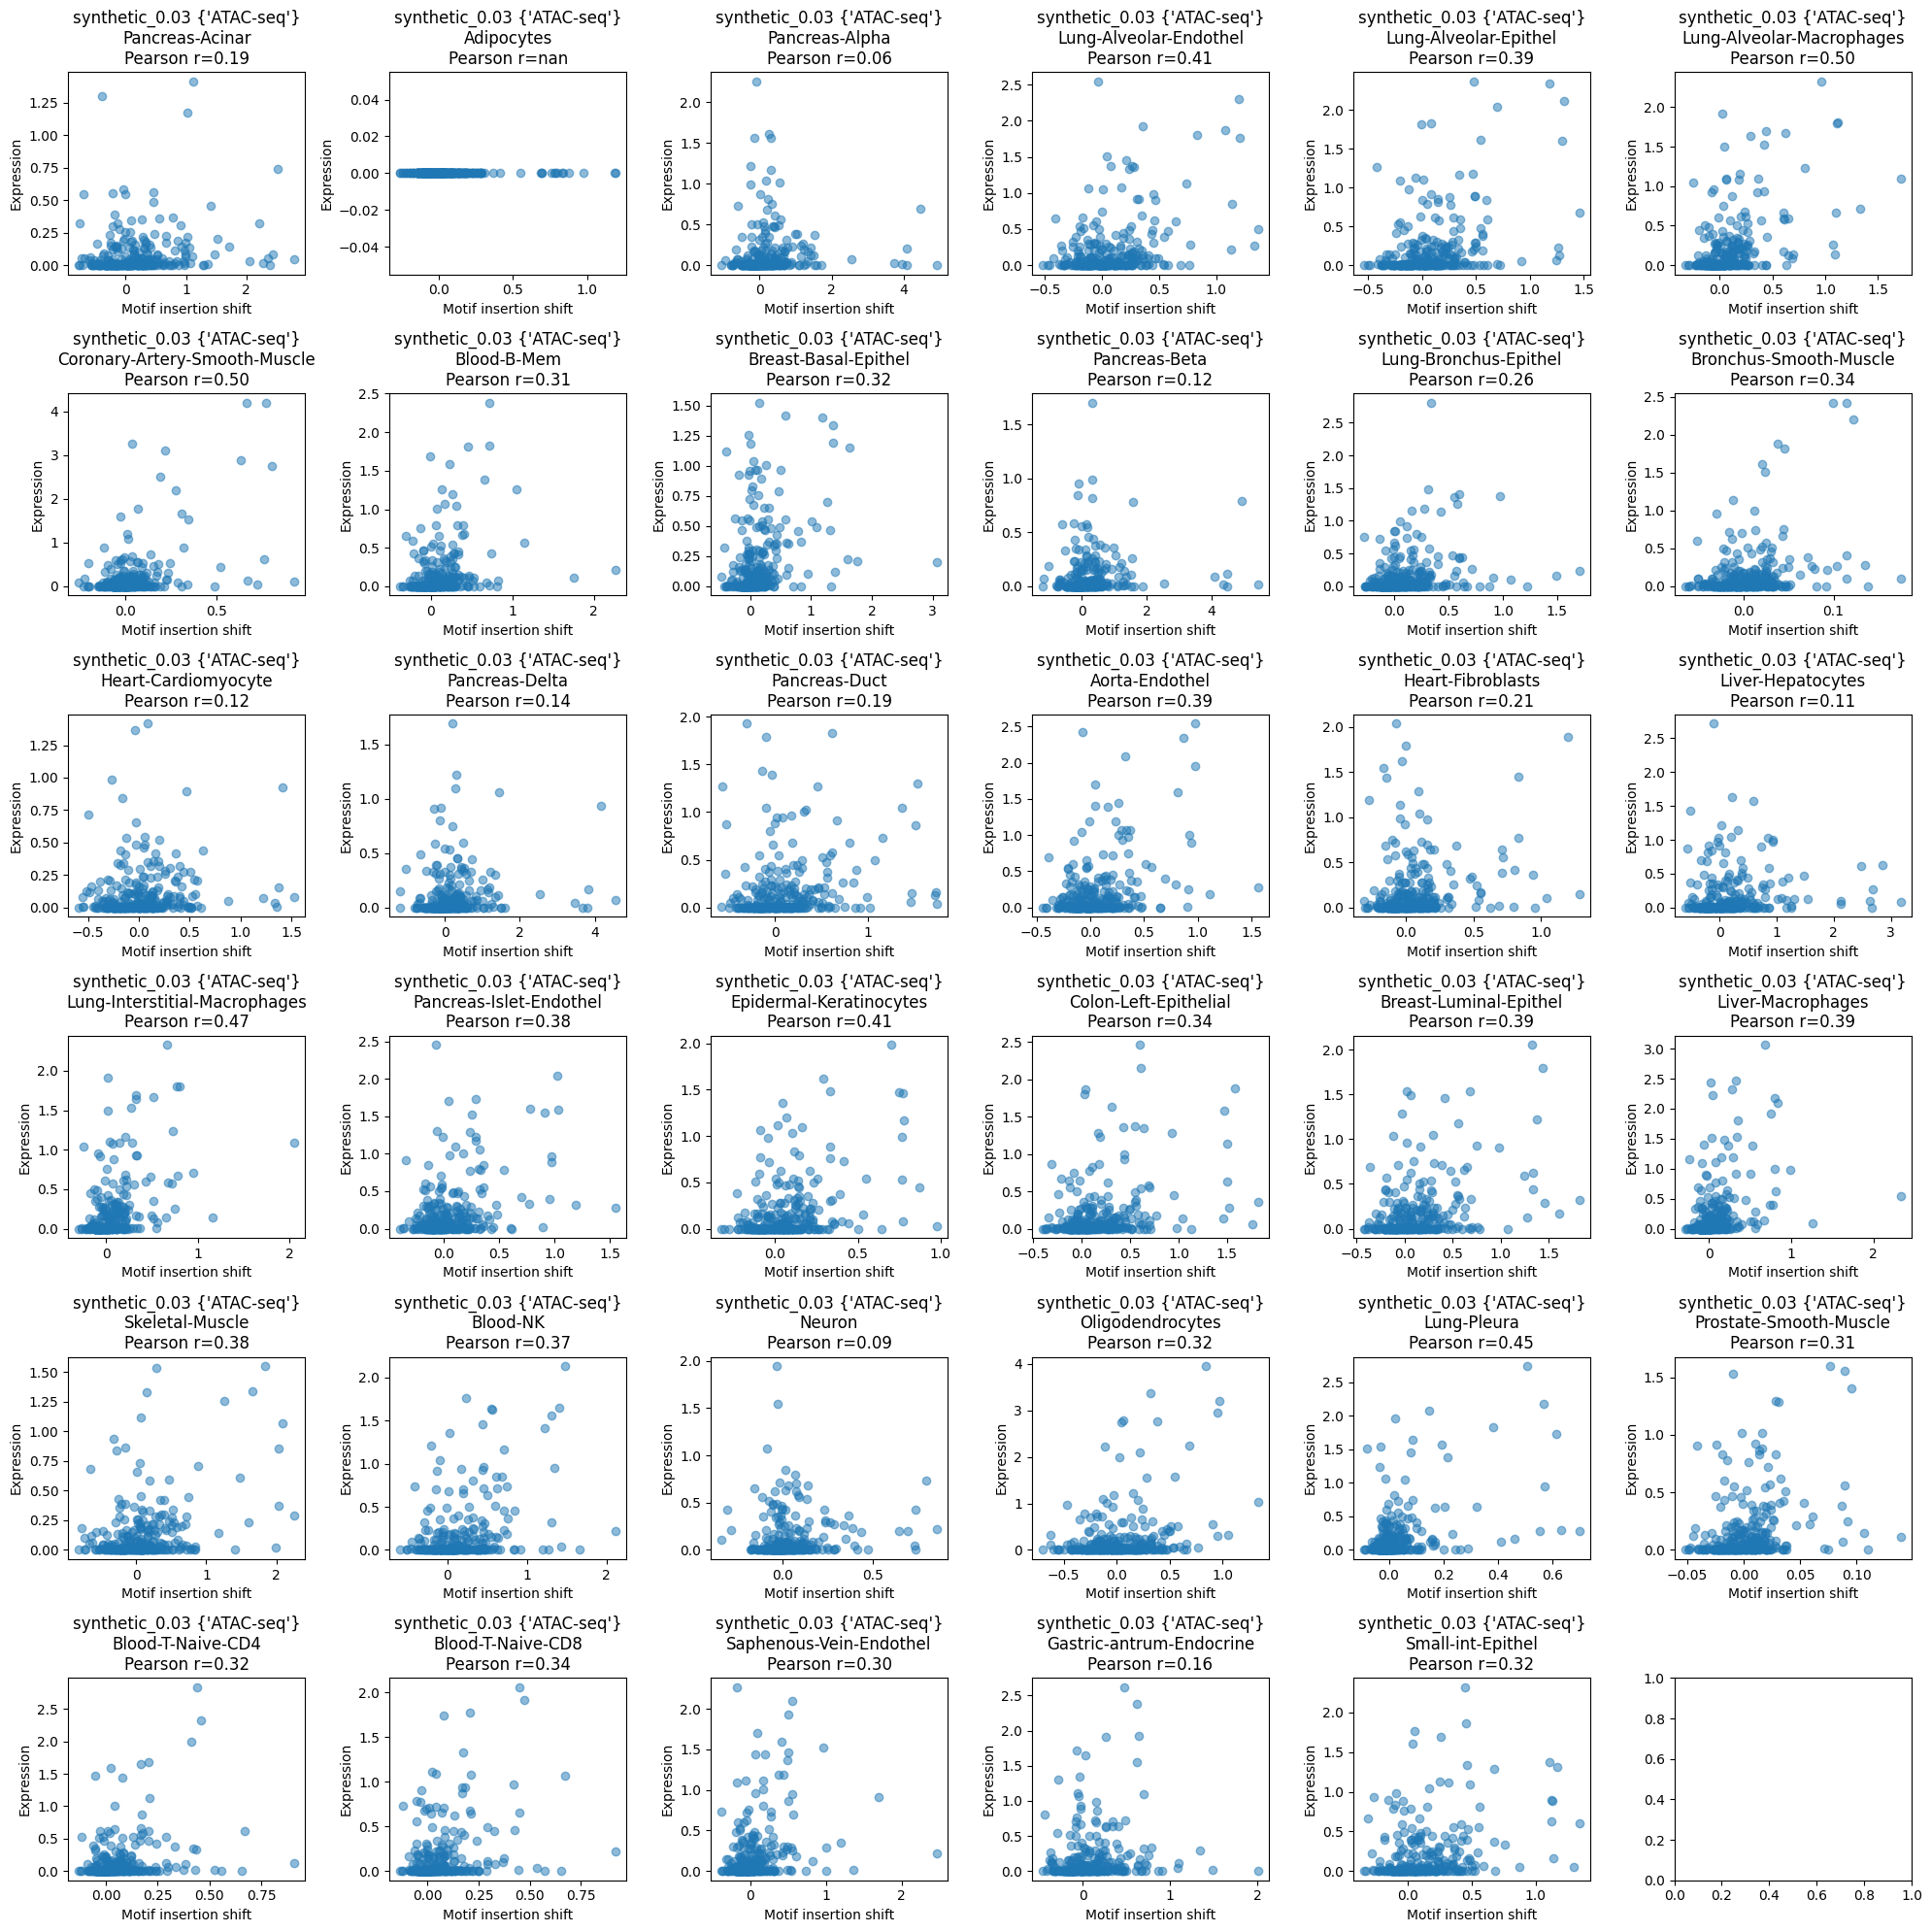

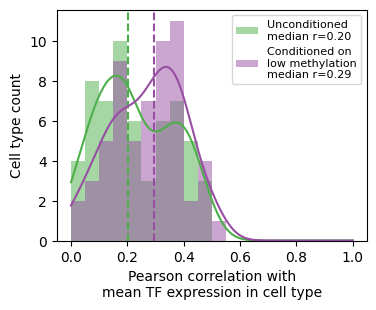

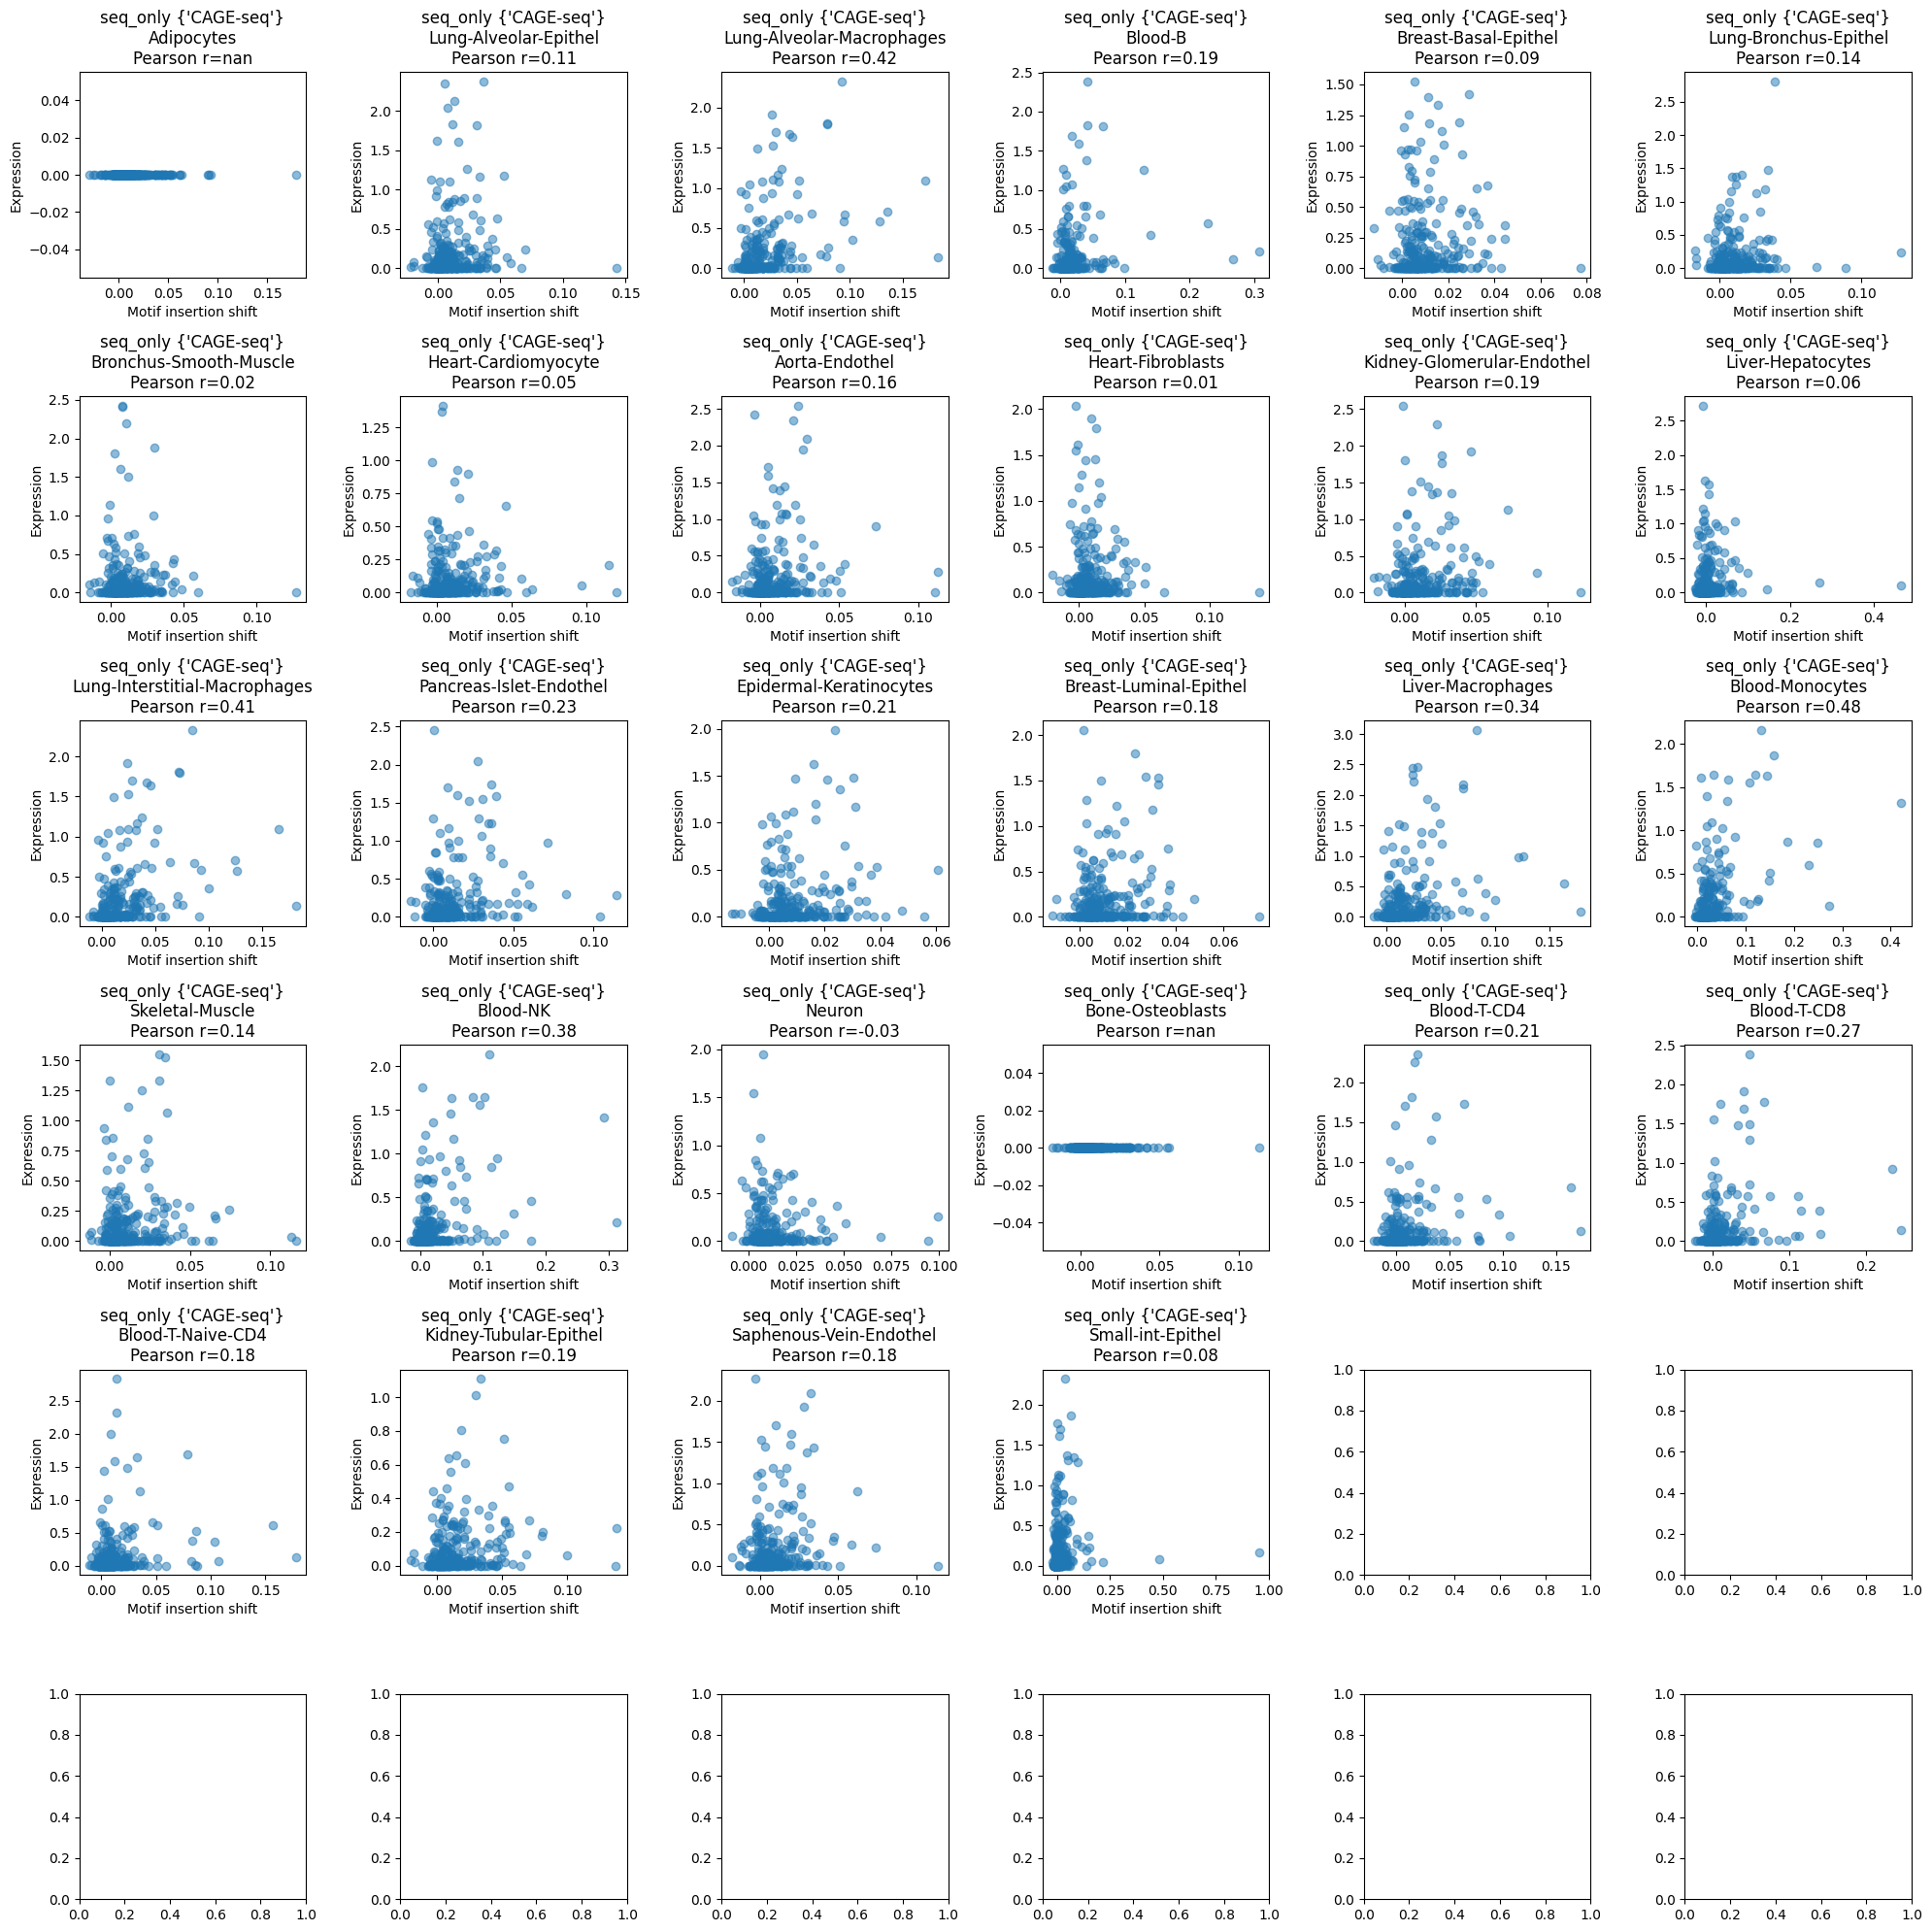

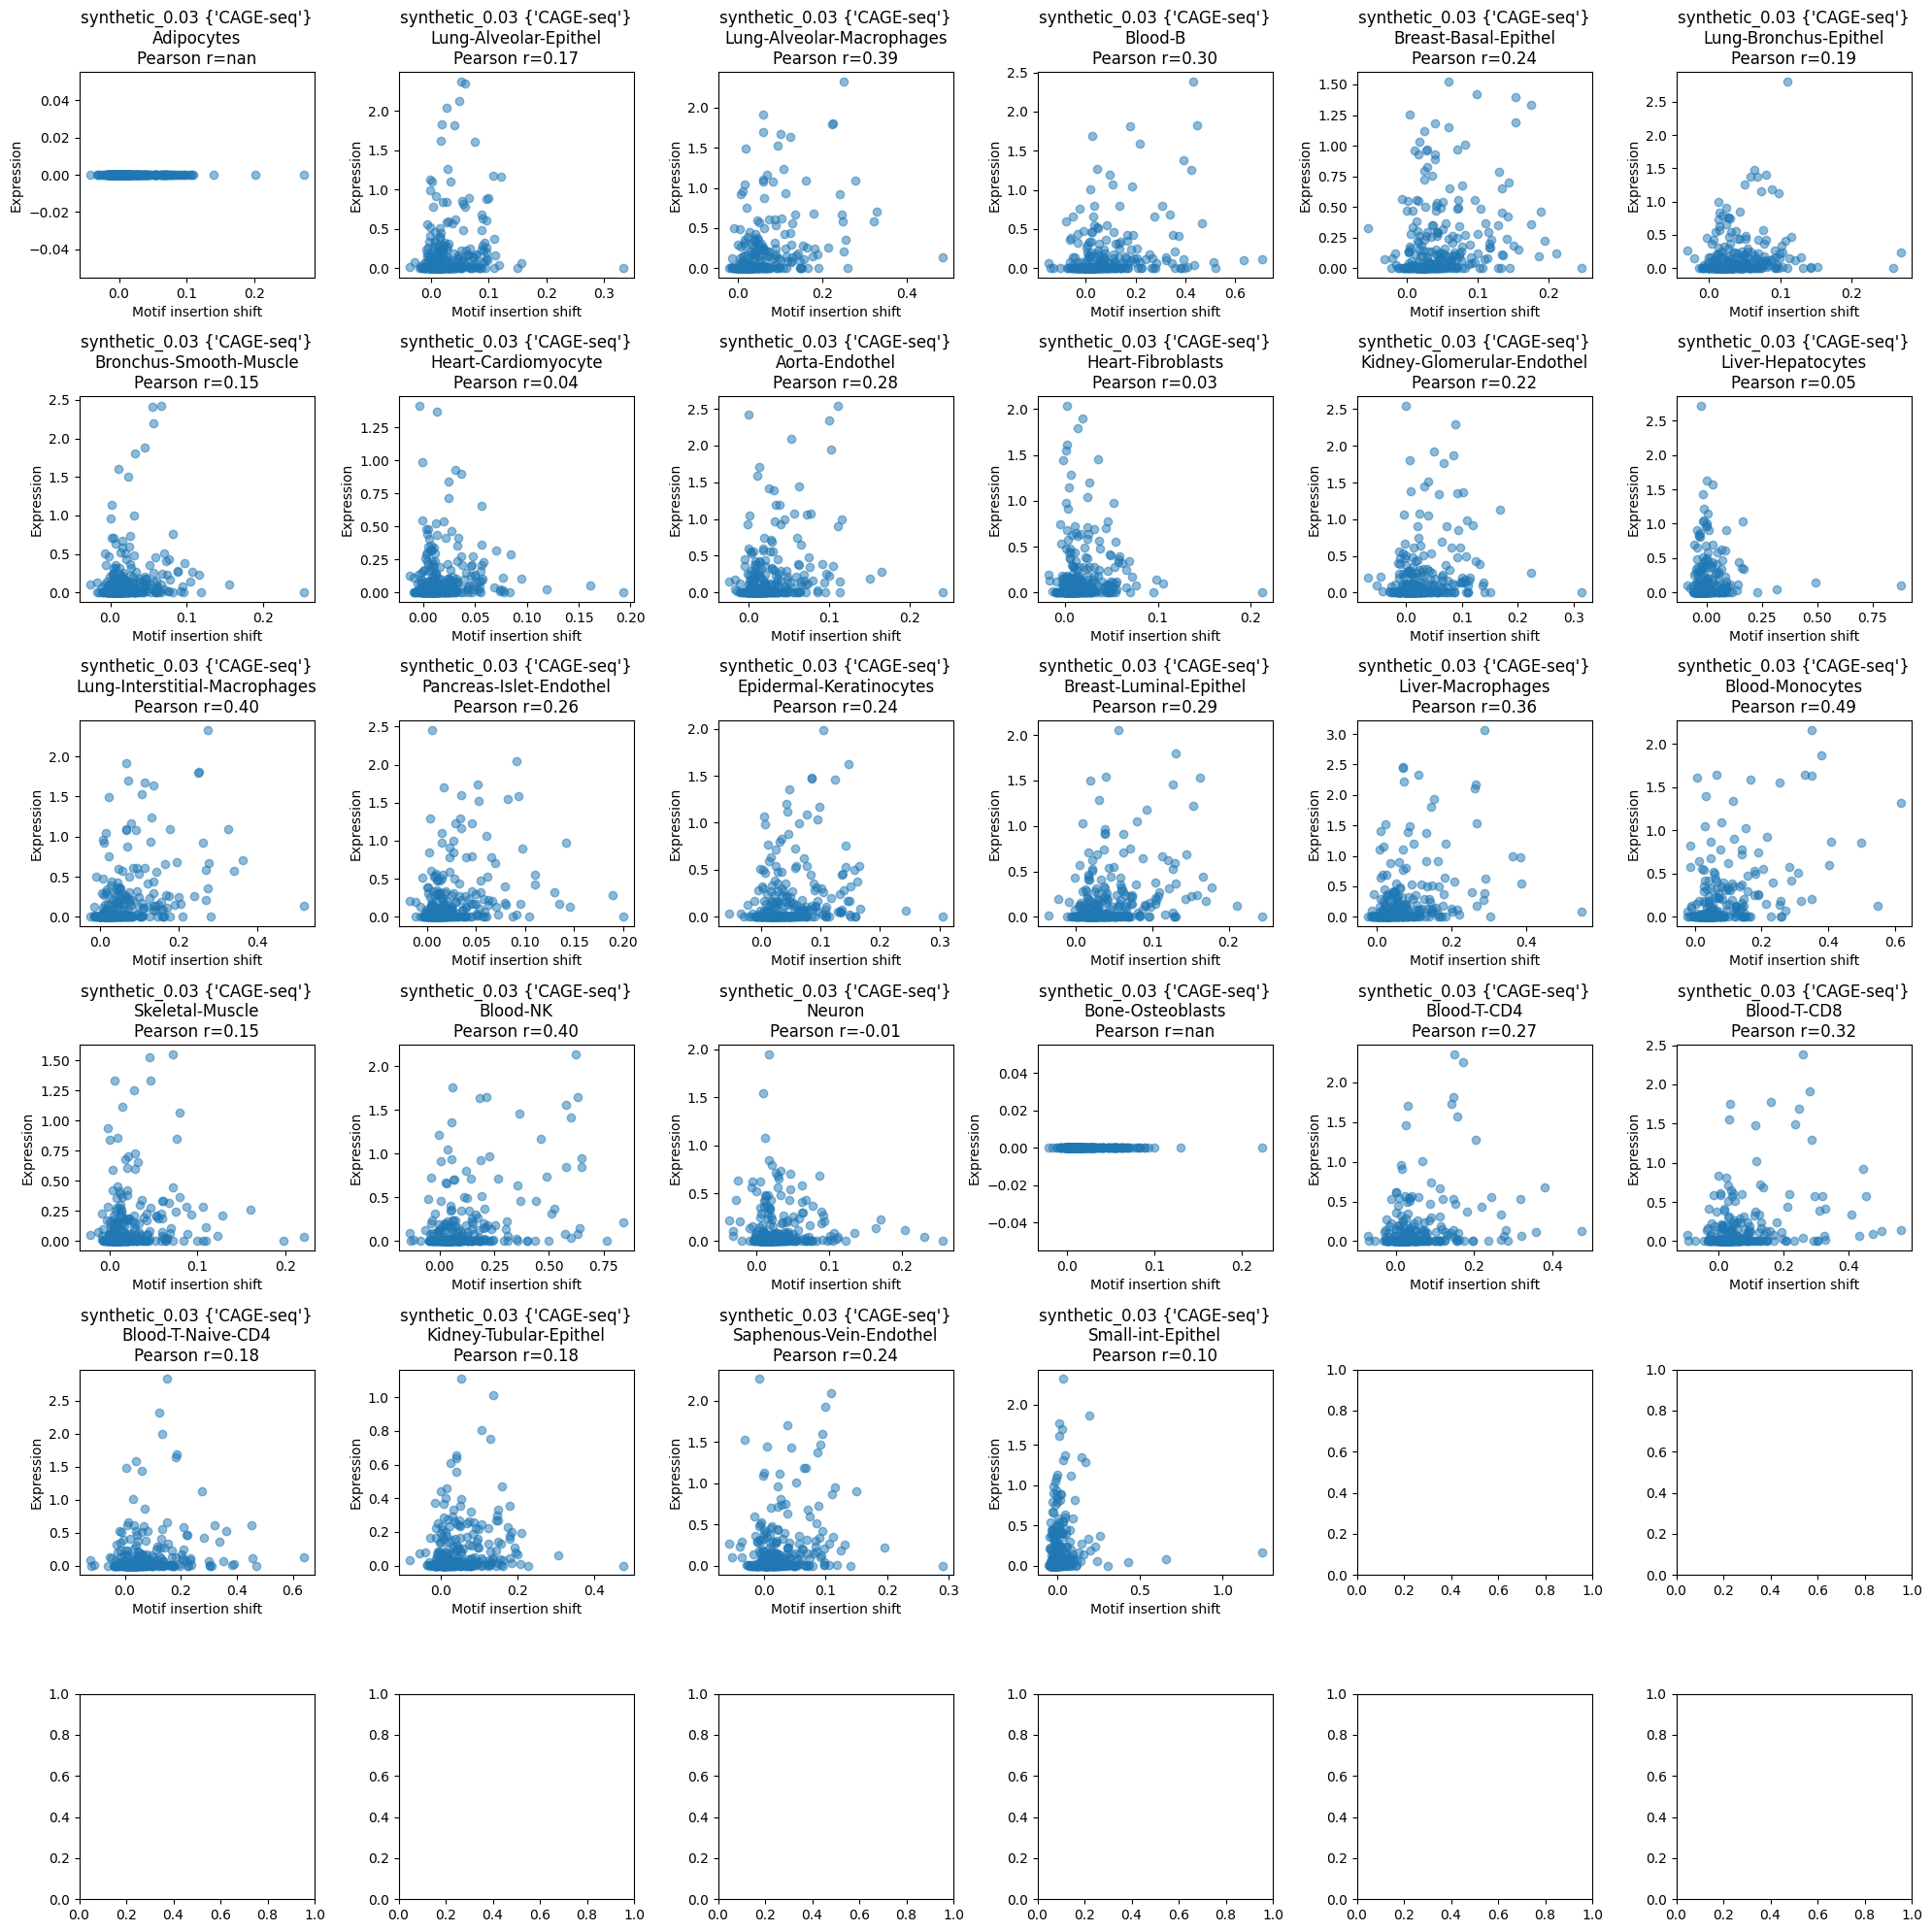

In [30]:
pearsons = defaultdict(list)
spearmans = defaultdict(list)
labels = dict()
tf_celltypewise_insertions = defaultdict(lambda: defaultdict(list))  # [model][tf] -> list over cell types
tf_celltypewise_expression = defaultdict(lambda: defaultdict(list))  # [model][tf] -> list over cell types
seq_model = "seq_only"
low_methylation = "synthetic_0.03"
high_methylation = "synthetic_0.95"
# fig.suptitle(f"Correlation between motif insertion shifts and\nTF expression by cell type")
colors = plt.get_cmap('Set1').colors
for data_types_idx,data_types_subset in enumerate([{"ATAC-seq",},{"CAGE-seq"}]):
    fig, ax = plt.subplots(figsize=(4,3))
    for description, model in ("Unconditioned",seq_model), ("Conditioned on\nlow methylation",low_methylation):
        labels[model] = description
        tasks_to_run = [task_index for task_index, data_type in list(data_types_by_description[model].values())[0].items() if data_type in data_types_subset]
        fig_array_size = int(np.ceil(np.sqrt(len(tasks_to_run))))
        print(fig_array_size)
        scatterfig, scatteraxs = plt.subplots(fig_array_size,fig_array_size,figsize=(20,20))
        for celltype_idx,celltype in enumerate(tqdm(tasks_to_run)):
            celltype_inserted_mean = np.array([np.array((celltypewise_dict[celltype])) for celltypewise_dict in background_subtracted_mean_by_description[model].values()])
            celltype_expression_mean = np.array([np.array([tf_expression_df[tf_expression_df["TF"]==tf][task_index_to_expression_column[celltype]].values[0]
                for tf in background_subtracted_mean_by_description[model].keys()])]).squeeze()
            for tf_idx, tf in enumerate(background_subtracted_mean_by_description[model].keys()):
                tf_celltypewise_insertions[model][tf].append(celltype_inserted_mean[tf_idx])
                tf_celltypewise_expression[model][tf].append(celltype_expression_mean[tf_idx])
            corr, pval = pearsonr(celltype_inserted_mean, celltype_expression_mean)
            pearsons[model].append(corr)
            scatteraxs[celltype_idx//fig_array_size, celltype_idx%fig_array_size].scatter(celltype_inserted_mean, celltype_expression_mean,alpha=0.5)
            strip_str = "[]'"
            scatteraxs[celltype_idx//fig_array_size, celltype_idx%fig_array_size].set_title(
                f"{model} {data_types_subset}\n{list(io_mappings_df[io_mappings_df['absolute_channel']==celltype]['methylation_files'].values)[0].strip(strip_str)}\nPearson r={corr:0.2f}")
            scatteraxs[celltype_idx//fig_array_size, celltype_idx%fig_array_size].set_xlabel("Motif insertion shift")
            scatteraxs[celltype_idx//fig_array_size, celltype_idx%fig_array_size].set_ylabel("Expression")
            corr, pval = spearmanr(celltype_inserted_mean, celltype_expression_mean)
            spearmans[model].append(corr)
        scatterfig.tight_layout()
    for model in pearsons.keys():
        ax.hist(
            pearsons[model],
            bins=np.arange(0,1,0.05),
            label=f"{labels[model]}\nmedian r={np.nanmedian(pearsons[model]):0.2f}",
            alpha=0.5,
            color=colors[2] if model == seq_model else colors[3],
        )
        kde = gaussian_kde([pearson for pearson in pearsons[model] if not np.isnan(pearson)])
        x_range = np.linspace(0, 1, 300)
        ax.plot(x_range, kde(x_range) * len(pearsons[model]) * 0.05, color=colors[2] if model == seq_model else colors[3], linewidth=1.5)
        ax.axvline(np.nanmedian(pearsons[model]), color=colors[2] if model == seq_model else colors[3], linestyle="--")

    # ax.set_title(f"{','.join(data_types_subset)}")
    ax.set_xlabel(f"Pearson correlation with\nmean TF expression in cell type")
    ax.set_ylabel("Cell type count")
    ax.legend(fontsize=8)
    fig.savefig(f"pdfs/motif_insertion__{','.join(data_types_subset)}_pearson_hist_vs_expression.pdf", format="pdf", bbox_inches="tight")

    # tf_pearsons = defaultdict(list)
    # tf_exp_means = defaultdict(list)
    # tf_exp_cvs = defaultdict(list)
    # cv_threshold = 1.0
    # for model in [seq_model, low_methylation]:
    #     for tf in tf_celltypewise_insertions[model]:
    #         ins = np.array(tf_celltypewise_insertions[model][tf])
    #         exp = np.array(tf_celltypewise_expression[model][tf])
    #         exp_mean = np.mean(exp)
    #         exp_cv = np.std(exp) / exp_mean if exp_mean > 0 else 0.0
    #         tf_exp_means[model].append(exp_mean)
    #         tf_exp_cvs[model].append(exp_cv)
    #         if np.std(ins) > 0 and exp_mean > 0.1:
    #             corr, _ = pearsonr(ins, exp)
    #             tf_pearsons[model].append(corr)
    #         else:
    #             tf_pearsons[model].append(np.nan)
    #     axs[1,data_types_idx].hist(tf_pearsons[model], bins=np.arange(-1,1,0.05), label=f"{model}\nmean {np.nanmean(np.array(tf_pearsons[model])):0.2f}", alpha=0.5)
    #     axs[1,data_types_idx].set_title(f"Pearson correlation across cell types, for each TF\n{data_types_subset}")
    #     axs[1,data_types_idx].set_xlabel("Pearson r")
    #     axs[1,data_types_idx].set_ylabel("Count")
    #     axs[1,data_types_idx].legend()
    #     axs[2,0].hist(tf_exp_means[model], label=f"{model}\nmean {np.nanmean(np.array(tf_exp_means[model])):0.2f}", alpha=0.5)
    #     axs[2,1].hist(tf_exp_cvs[model], label=f"{model}\nmean {np.nanmean(np.array(tf_exp_cvs[model])):0.2f}", alpha=0.5)

    

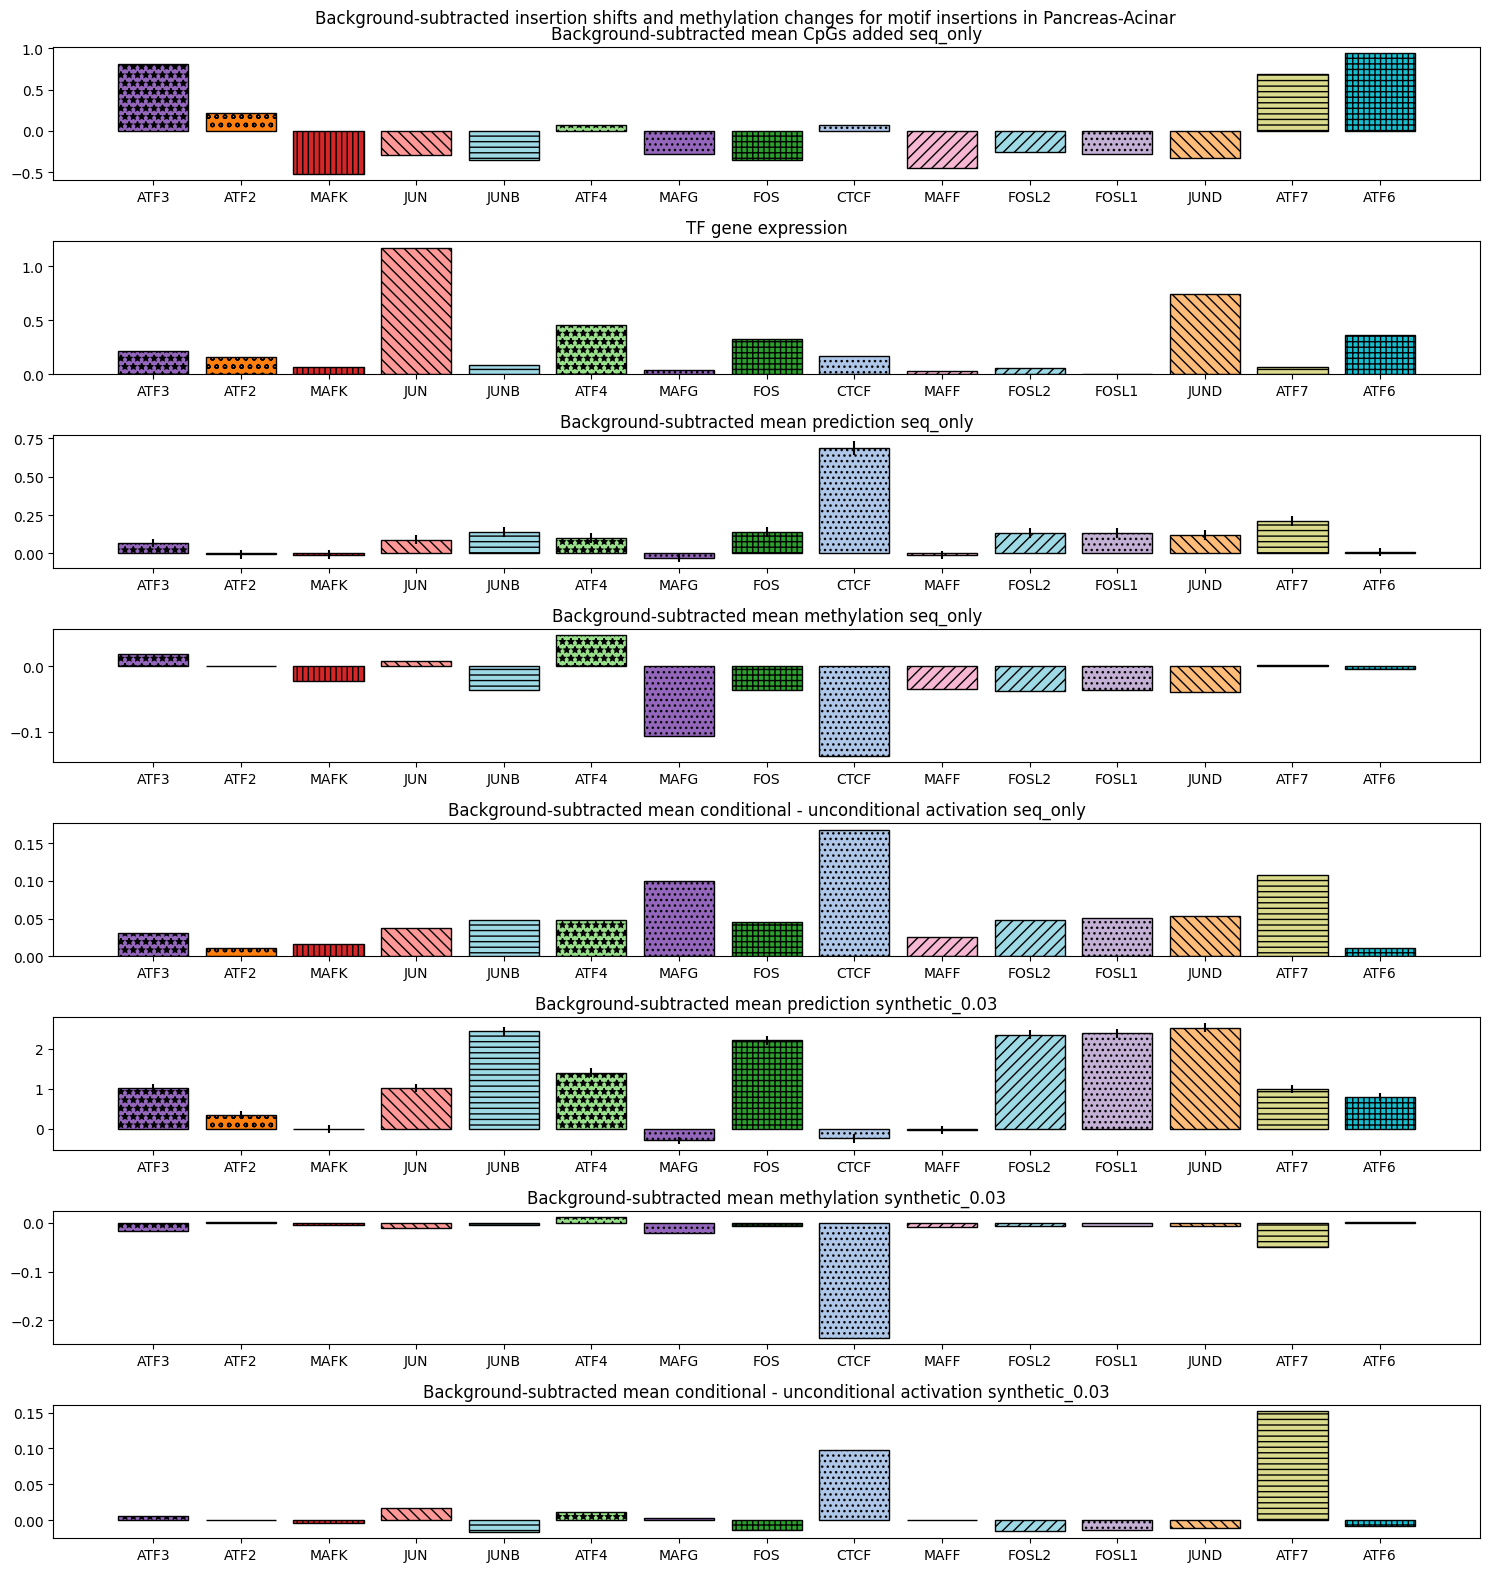

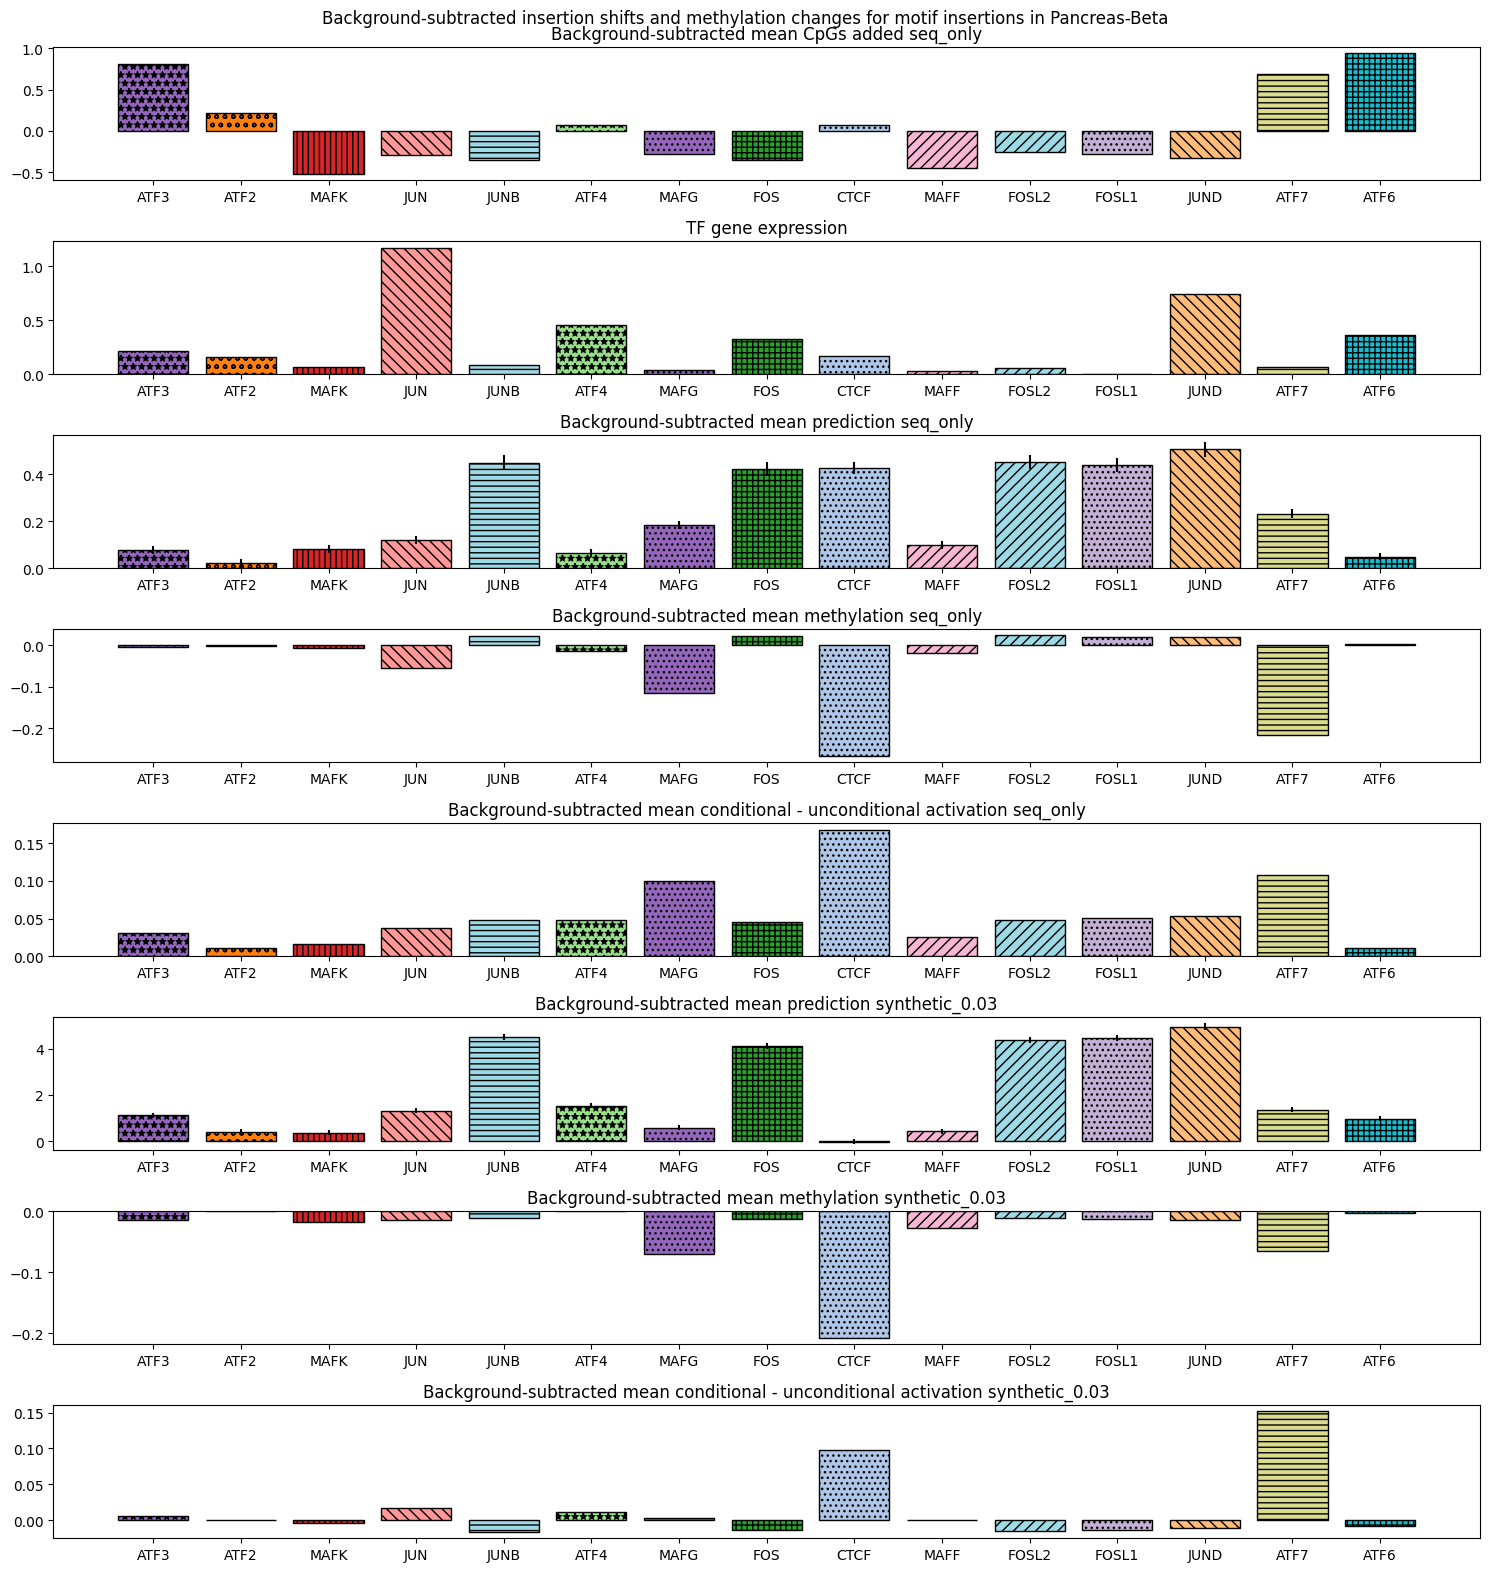

In [11]:
# # nested: pickled_dict_description -> motif -> celltype_task -> value
# background_subtracted_mean_by_description = {}
# background_subtracted_std_by_description = {}
# background_subtracted_methylation_mean_by_description = {}
# data_types_by_description = {}

# # nested: pickled_dict_description -> motif -> value
# background_subtracted_cpgs_added_by_description = {}
# background_subtracted_mean_conditional_activations_by_description = {}
# background_subtracted_mean_unconditional_activations_by_description = {}

tfs_subset = set(tf_annotations[tf_annotations["AP-1 bool"]]["TF name"].tolist() + ["CTCF"])


# tfs_subset = tf_subset_by_model["synthetic_0.03"]

descriptions = "seq_only", "synthetic_0.03"

cell_types = "Pancreas-Acinar","Pancreas-Beta"
cell_tasks = [io_mappings_df[(io_mappings_df["methylation_files"].str.contains(cell_type)) & (io_mappings_df["data_type"] == "ATAC-seq")]["absolute_channel"].values[0] for cell_type in cell_types]

colors = plt.cm.tab20(np.linspace(0, 1, 20))
patterns = ['...', '///', '|||', '\\\\\\', '---', '+++', 'xxx', '', '**', 'oo', 'OO']
tf_names = [tf_name for tf_name in background_subtracted_mean_by_description[low_methylation].keys()]
tf_colors = [colors[i%20] for i in range(len(tf_names))]
tf_patterns = [patterns[i%len(patterns)] for i in range(len(tf_names))]

for cell_type_idx, (cell_type, celltype_task) in enumerate(zip(cell_types,cell_tasks)):
    num_plots_per_desc = 3
    num_universal_plots = 2 #if cell_type_idx == 0 else 0  # only plot CpGs added and conditional-unconditional shift for the first cell type to avoid redundancy
    fig, axs = plt.subplots(
        len(descriptions)*num_plots_per_desc + num_universal_plots, 1, figsize=(len(tfs_subset),2*(num_plots_per_desc*len(descriptions)+num_universal_plots)),
    )
    fig.suptitle(f"Background-subtracted insertion shifts and methylation changes for motif insertions in {cell_type}")
    for description_idx, description in enumerate(descriptions):
        ordered_tf_subset = [
            tf for tf in tf_names if tf in tfs_subset
        ]
        expression_in_celltype = [
            tf_expression_df[tf_expression_df["TF"]==tf][task_index_to_expression_column[celltype_1]].values[0]
            for tf in ordered_tf_subset
        ]
        tf_colors_subset = [
            tf_colors[tf_names.index(tf)]
            for tf in ordered_tf_subset
        ]
        tf_patterns_subset = [
            tf_patterns[tf_names.index(tf)]
            for tf in ordered_tf_subset
        ]
        mean_insertions_subset  = [
            value
            for motif, celltypewise_dict in background_subtracted_mean_by_description[description].items()
            for celltype, value in celltypewise_dict.items()
            if celltype == celltype_task and motif in tfs_subset
        ]
        std_insertions_subset  = [
            value
            for motif, celltypewise_dict in background_subtracted_std_by_description[description].items()
            for celltype, value in celltypewise_dict.items()
            if celltype == celltype_task and motif in tfs_subset
        ]
        methylation_mean_subset  = [
            value
            for motif, celltypewise_dict in background_subtracted_methylation_mean_by_description[description].items()
            for celltype, value in celltypewise_dict.items()
            if celltype == celltype_task and motif in tfs_subset
        ]
        cpgs_added_subset = [
            value
            for motif, value in background_subtracted_cpgs_added_by_description[description].items()
            if motif in tfs_subset
        ]
        conditional_activation_subset = [
            value
            for motif, value in background_subtracted_mean_conditional_activations_by_description[description].items()
            if motif in tfs_subset
        ]
        unconditional_activation_subset = [
            value
            for motif, value in background_subtracted_mean_unconditional_activations_by_description[description].items()
            if motif in tfs_subset
        ]
        if description_idx == 0:
            axs[description_idx*num_plots_per_desc].bar(
                x=ordered_tf_subset,
                height=cpgs_added_subset,
                color=tf_colors_subset,
                hatch=tf_patterns_subset,
                edgecolor='black',
                linewidth=1,
            )
            axs[description_idx*num_plots_per_desc].set_title(f"Background-subtracted mean CpGs added {description}")
            axs[description_idx*num_plots_per_desc+1].bar(
                x=ordered_tf_subset,
                height=expression_in_celltype,
                color=tf_colors_subset,
                hatch=tf_patterns_subset,
                edgecolor='black',
                linewidth=1,
            )
            axs[description_idx*num_plots_per_desc+1].set_title(f"TF gene expression")
        axs[description_idx*num_plots_per_desc+num_universal_plots].bar(
            x=ordered_tf_subset,
            height=mean_insertions_subset,
            yerr=np.array(std_insertions_subset)/np.sqrt(500),
            color=tf_colors_subset,
            hatch=tf_patterns_subset,
            edgecolor='black',
            linewidth=1,
        )
        axs[description_idx*num_plots_per_desc+num_universal_plots].set_title(f"Background-subtracted mean prediction {description}")
        axs[description_idx*num_plots_per_desc+num_universal_plots+1].bar(
            x=ordered_tf_subset,
            height=methylation_mean_subset,
            color=tf_colors_subset,
            hatch=tf_patterns_subset,
            edgecolor='black',
            linewidth=1,
        )
        axs[description_idx*num_plots_per_desc+num_universal_plots+1].set_title(f"Background-subtracted mean methylation {description}")
        axs[description_idx*num_plots_per_desc+num_universal_plots+2].bar(
            x=ordered_tf_subset,
            height=np.abs(np.array(conditional_activation_subset).mean(axis=(1,2))) - np.abs(np.array(unconditional_activation_subset).mean(axis=(1,2))),
            color=tf_colors_subset,
            hatch=tf_patterns_subset,
            edgecolor='black',
            linewidth=1,
        )
        axs[description_idx*num_plots_per_desc+num_universal_plots+2].set_title(f"Background-subtracted mean conditional - unconditional activation {description}")
    fig.tight_layout()